<font size="6" color="black">Module 2 – End to End Machine Learning Project</font>

<img src="images_module02/module02.png" width="600"/>


# Recap
---

<img src="images_module02/basics_recap.png" width="600"/>

The process of stating a parameterized mapping, defining an error function that scores that mapping using your training data, and then finding the parameters that minimize that error, is common to all machine learning algorithms. 

But there are a lot of details we have so far glossed over: 
- How should you clean and prepare your data?
- How do you choose the machine learning model or the features you train on?
- How can you build automated, reproducible training and prediction pipelines?
- How should you approach solving machine learning problems generally?

We’ll begin to answer these questions by solving an ML problem end-to-end using the scikit-learn python library. 

# Module Overview
***

**Learning Goal:** At the end of this module, you should be able to build your own basic data preprocessing, model training, and model inference pipelines in Python. 



*Welcome to Machine Learning Housing Corp.! Your task is to predict median house values in Californian districts, given a number of features from these districts.*

**Machine Learning Project Workflow Overview**
1. Frame problem and look at the big picture
2. Get the data
3. Explore, Discover, and visualize the data to gain insights
    - Remember to create a test set to test final models on!
4. Prepare the data to better expose the underlying data patterns to ML algorithms
5. Explore many different models and short-list the best ones
6. Fine-tune models and combine into an even better model
7. Present your solution
8. Launch, monitor, and maintain your system

In [3]:
# Common imports
import numpy as np
import os
import tarfile
from six.moves import urllib # NB: 'six' provides Python 2/3 - agnostic versions of common python libraries
import pandas as pd

# to make this notebook's output stable across runs
np.random.seed(42)

# To plot pretty figures
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12

# Ignore useless warnings (see SciPy issue #5998)
import warnings
warnings.filterwarnings(action="ignore", message="^internal gelsd")

# Look at the BIG PICTURE
***
The first task you are asked to perform is to build a model of **housing prices in California using the California census data**. This data has various district-level metrics such as: 
- population size
- median income
- location (longitude and latitude)
- proximity to an ocean

Our target variable is:
- median housing price 



### Frame the problem:
The first question to ask your boss is what exactly is the business objective; **building a model is probably not the end goal.** 
- How does the company expect to use and benefit from this model? 
- How accurate does it need to be (how do we even define "accurate")?
- Does it need to run live (i.e., does it need to perform speedy inferences)?

> Thought experiment: imagine you were building an internal app for a property developer, that routinely needs to estimate the market value of potential new developments in order to decide where to invest. How would you answer these questions?

<img src="images_module02/full_ml_pipeline.png" width="600"/>




### What is the current non-ML solution?
- What is the current solution? Manual estimations?  Econometric models? Crystal ball?
- Establish a baseline?
- What is current accuracy / error rate of the existing methodology?


### Initial ML specs and design
- Is it supervised, unsupervised, or Reinforcement Learning? 
- Is it a classification task, a regression task, or something else
- Should you use batch learning or online learning techniques? 

### Select an error metric
Your next step is to select a performance measure. For regression problems, you will typically want to chose one of  **Root Mean Square Error (RMSE)** and **Mean Absolute Error (MAE)**. Both the RMSE and the MAE are ways to measure the **distance between two vectors:** the vector of predictions and the vector of target values.

#### RMSE

<img src="images_module02/rmse.png" width="300"/>

- RMSE measures the **standard deviation of the errors the system makes in its predictions.** 
- Computing the root of a sum of squares (RMSE) corresponds to the **Euclidean norm**. It is also called the L2 norm, written $\| x\|_2$ .
- For example, an RMSE equal to 50,000 means that about 68% of the system’s predictions fall within 50,000 of the actual value, and about 95% of the predictions fall within 100,000 of the actual value.
    - NOTE: This assumes that errors are normally distributed!


#### MAE

<img src="images_module02/mae.png" width="300"/>

- MAE calculates the **average absolute deviation of the errors the system makes**, and it is generally less sensitive to outliers. 
- Computing the sum of absolutes (MAE) corresponds to the L1 norm, written  $\| x\|_1$. This is sometimes called the **Manhattan norm** because it measures the distance between two points in a city if you can only travel along orthogonal city blocks.
- Suppose that there are **many outlier districts** in the housing price dataset. In that case, mean absolute error may be the right choice.


#### Notation

This equations above introduces several very common Machine Learning notations that we will use throughout this course: 
- $m$ is the number of instances in the dataset you are measuring the RMSE (or MAE) on. For example, if you are evaluating the RMSE on a validation set of 2,000 districts, then $m = 2,000$.
- $\textbf{x}^{(i)} $ is a vector of all the **feature values (excluding the label)** of the $i^{th}$ instance in the dataset
    - You may also see this notation in *vectorized format*, where $\textbf{X}$ is a matrix containing all the feature values (excluding labels) of all instances in the dataset.  
- $y^{(i)} $ is its label (the desired output value for that instance).
- $h$ is your system’s prediction function, also called a *hypothesis*. When your system is given an instance’s feature vector $\textbf{x}^{(i)} $ , it outputs a predicted value $\hat{y}^{(i)} $ for that instance.
    - $h(\textbf{x}^{(i)}) =  \hat{y}^{(i)} $
- $\text{RMSE}(\textbf{X} , h )$ is the cost function measured on the set of examples using your hypothesis $h$ .


We use *lowercase italic* font for scalar values (such as $m$ or $y^{( i )}$) and function names (such as $h$ ), **lowercase bold** font for vectors (such as $\textbf{x}^{(i)} $ ), and uppercase bold font for matrices (such as $\textbf{X}$ ). 

In [2]:
# Loss function using numpy
y = np.random.randint(1,10,10)
y_hat = np.random.randint(1,15,10)

def rmse(y, yhat):
    return np.mean((y_hat-y)**2)**(1/2)

def mae(y, yhat):
    return np.mean(abs(y_hat-y))

print(rmse(y, y_hat))
print(mae(y, y_hat))

3.872983346207417
3.0


In [3]:
# Loss function using sklearn
from sklearn.metrics import mean_squared_error, mean_absolute_error
print(mean_squared_error(y, y_hat)**(1/2))
print(mean_absolute_error(y, y_hat))

3.872983346207417
3.0


In [4]:
# L2 vector norm using numpy and sklearn
# sum(abs(x)**ord)**(1./ord)
diff = y_hat - y
ord=2
print(sum(abs(diff)**ord)**(1./ord))
print(np.linalg.norm(diff))

12.24744871391589
12.24744871391589


A quick primer on [norms](https://towardsdatascience.com/a-quick-guide-to-understanding-vectors-norms-84eb802f81f9)

[New version](https://machinelearningmastery.com/vector-norms-machine-learning/)

# Get the data
***

In typical environments your data would be available in a relational database (or some other common datastore) and spread across multiple tables/documents/files. For this project things are much simpler: you will just download a single compressed file, **housing.tgz**, which contains a comma-separated value (CSV) file called **housing.csv** with all the data.

**Automating the process of fetching the data is also useful if you need to install the dataset on multiple machines.**

In [1]:
import os

# Check root dir
os.getcwd()

'c:\\Users\\Alavi\\Documents\\GitHub\\UofT-SCS-3253-095-Machine-Learning\\modules\\module-2'

In [5]:
# import urllib

# DOWNLOAD_ROOT = "https://raw.githubusercontent.com/ageron/handson-ml/master/"
HOUSING_PATH = os.path.join("..", "..", "data")
# HOUSING_URL = DOWNLOAD_ROOT + "datasets/housing/housing.tgz"

def fetch_housing_data(housing_url=HOUSING_URL, housing_path=HOUSING_PATH):
    print(f"Loading data from: {housing_url}" )
    print(f"Saving data to:    {housing_path}" )
    if not os.path.isdir(housing_path):
        os.makedirs(housing_path)
    
    tgz_path = os.path.join(housing_path, "housing.tgz")
    urllib.request.urlretrieve(housing_url, tgz_path)
    housing_tgz = tarfile.open(tgz_path)
    housing_tgz.extractall(path=housing_path)
    housing_tgz.close()
    
# fetch_housing_data()

def load_housing_data(housing_path=HOUSING_PATH):
    csv_path = os.path.join(housing_path, "housing.csv")
    return pd.read_csv(csv_path)

housing = load_housing_data()
print("DATA SHAPE:", housing.shape)
housing.head(10)

DATA SHAPE: (20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,NEAR BAY
6,-122.25,37.84,52.0,2535.0,489.0,1094.0,514.0,3.6591,299200.0,NEAR BAY
7,-122.25,37.84,52.0,3104.0,687.0,1157.0,647.0,3.1200,241400.0,NEAR BAY
8,-122.26,37.84,42.0,2555.0,665.0,1206.0,595.0,2.0804,226700.0,NEAR BAY
9,-122.25,37.84,52.0,3549.0,707.0,1551.0,714.0,3.6912,261100.0,NEAR BAY


In [6]:
housing.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='str')

In [7]:
housing.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [9]:
housing.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

**Issues at first glance?**

- total_bedrooms attribute has only 20,433 non-null values, meaning that 207 districts are missing this feature
- All attributes are numerical, **except the ocean_proximity field.** Its type is *object*, so it could hold any kind of Python object

In [10]:
housing["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [11]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


**Plotting distributions of the attributes**
- The `hist()` method relies on Matplotlib, which in turn relies on a **user-specified graphical backend** to draw on your screen. So before you can plot anything, you need to specify which backend Matplotlib should use. 
- The simplest option is to use Jupyter’s **magic** command `%matplotlib inline`. This tells Jupyter to **set up Matplotlib so it uses Jupyter’s own backend**. Plots are then rendered within the notebook itself. 
- Note that calling `show()` is optional in a Jupyter notebook, as **Jupyter will automatically display plots when a cell is executed.**

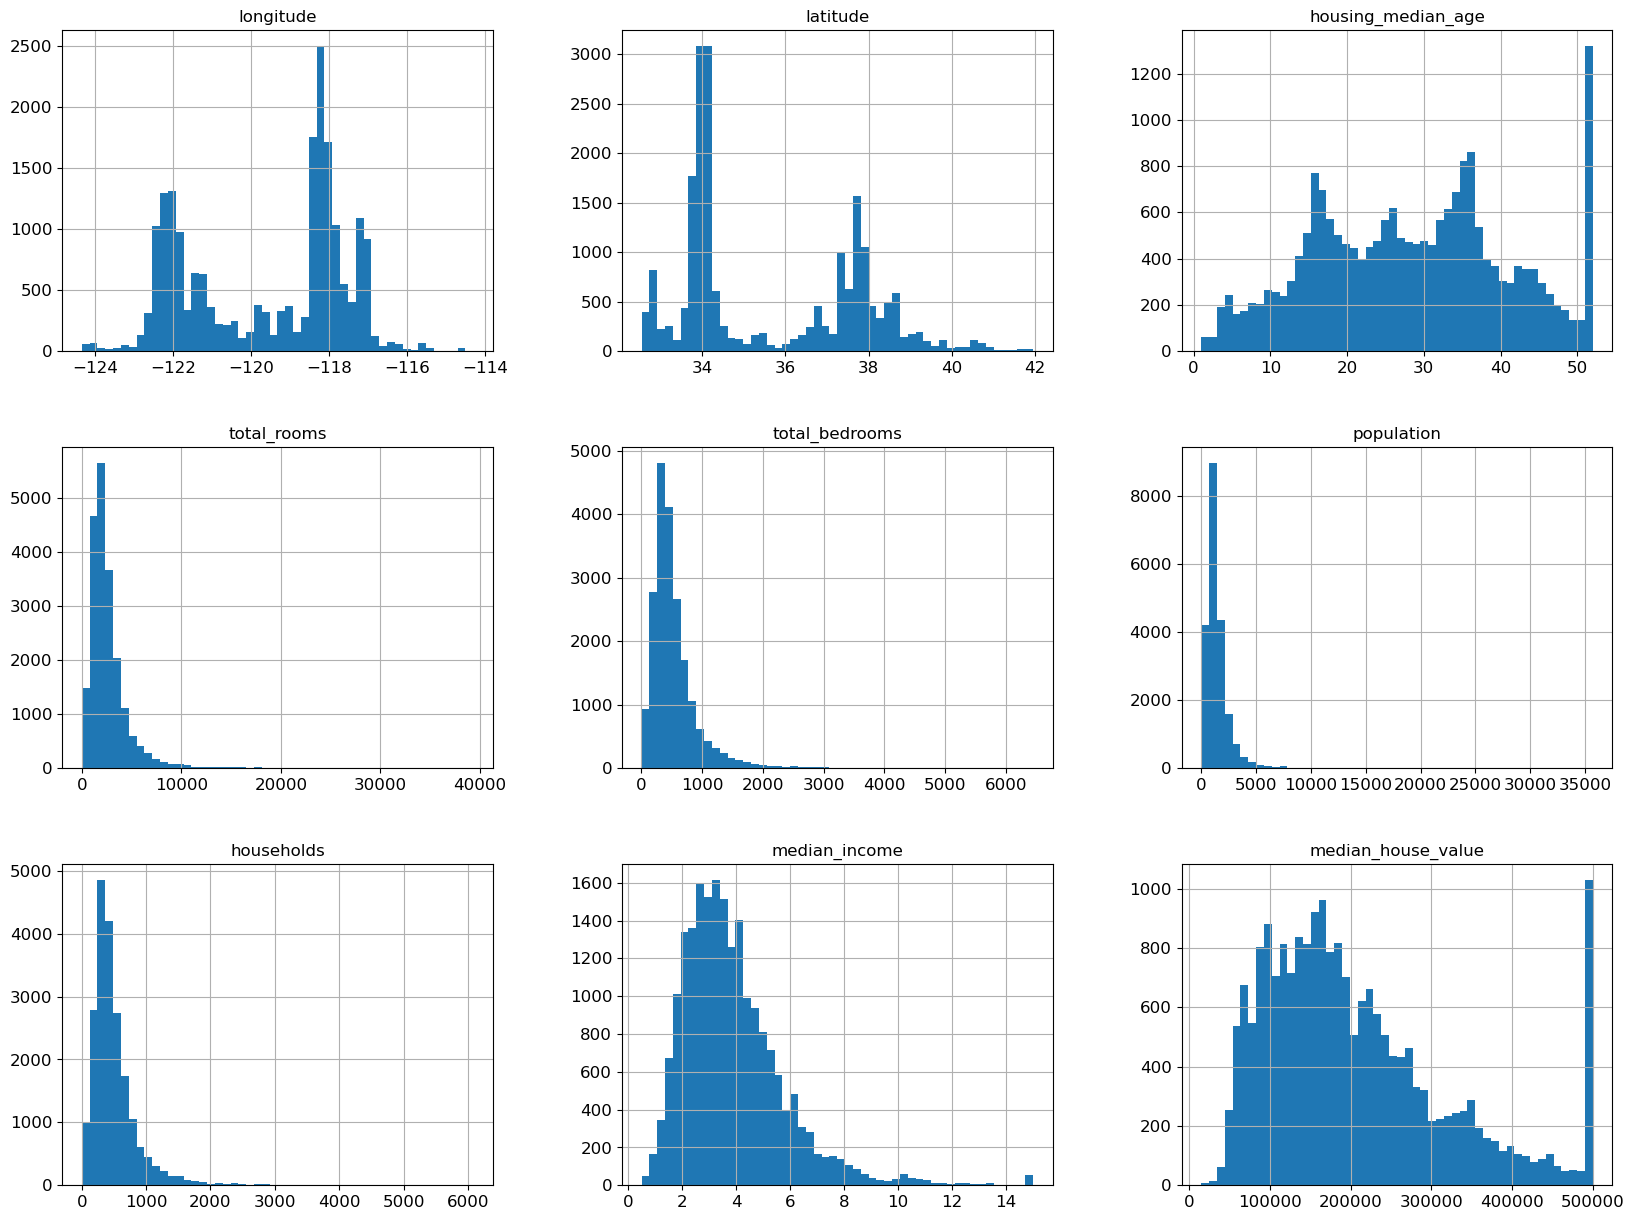

In [12]:
%matplotlib inline
import matplotlib.pyplot as plt
housing.hist(bins=50, figsize=(20,15)); #relies on matplotlib backend
# save_fig("attribute_histogram_plots")

plt.show()

There are a few things you might notice in these histograms: 
1. The median income attribute does not look like it is expressed in US dollars (USD). 
    - The data has been scaled and capped at 15 (actually, 15.0001) for higher median incomes, and at 0.5 (actually, 0.4999) for lower median incomes. 
    - The numbers represent roughly tens of thousands of dollars (e.g., 3 actually means about USD 30,000).
2. The housing median age and the median house value were also capped. The latter may be a serious problem since it is your target attribute (your labels). 
3. These attributes have **very different scales.**
4. Many histograms are **tail-heavy:** they extend much farther to the right of the median than to the left. This may make it a bit harder for some Machine Learning algorithms to detect patterns. 

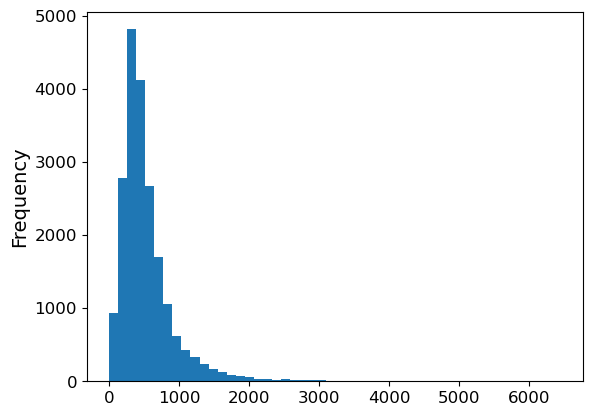

In [13]:
housing['total_bedrooms'].plot(kind='hist', bins=50);
plt.show()

In [14]:
housing['total_bedrooms_log'] = np.log(housing['total_bedrooms']);

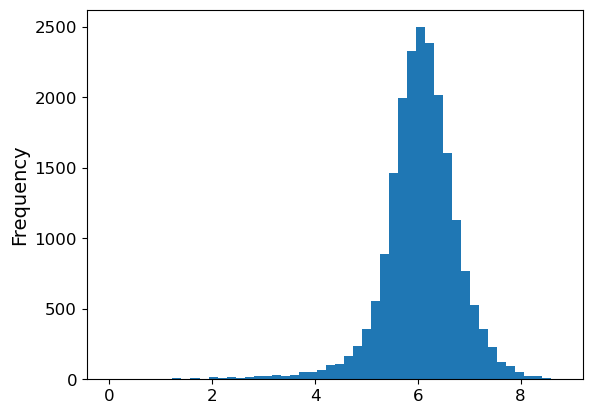

In [15]:
housing['total_bedrooms_log'].plot(kind='hist', bins=50);
plt.show()

In [16]:
# DROP LOG COLUMN
housing.drop('total_bedrooms_log', axis=1, inplace=True)

In [17]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## Create a Test Set


In [18]:
# to make this notebook's output identical at every run
np.random.seed(42)

In [19]:
import numpy as np

# For illustration only. Sklearn has train_test_split()
def split_train_test(data, test_ratio):
    shuffled_indices = np.random.permutation(len(data))
    test_set_size = int(len(data) * test_ratio)
    test_indices = shuffled_indices[:test_set_size]
    train_indices = shuffled_indices[test_set_size:]
    return data.iloc[train_indices], data.iloc[test_indices]

In [20]:
train_set, test_set = split_train_test(housing, 0.3)
print(len(train_set), "train +", len(test_set), "test")

14448 train + 6192 test


This solution will break the next time you fetch an updated dataset. To have a stable train/test split even after updating the dataset, a common solution is to **use each instance’s identifier to decide whether or not it should go in the test set**. 

- You could compute a **hash of each instance’s identifier and put that instance in the test set if the hash is lower than or equal to 20% of the maximum hash value.** 
- This ensures that the test set will remain consistent across multiple runs, even if you refresh the dataset. 
- The new test set will contain 20% of the new instances, but it will not contain any instance that was previously in the training set. 

Good read: [What does it mean to hash data and do I really care?](https://dataspace.com/big-data-applications/what-does-it-mean-to-hash-data/)

In [21]:
from zlib import crc32

def test_set_check(identifier, test_ratio):
    return crc32(np.int64(identifier)) & 0xffffffff < test_ratio * 2**32

def split_train_test_by_id(data, test_ratio, id_column):
    ids = data[id_column]
    in_test_set = ids.apply(lambda id_: test_set_check(id_, test_ratio))
    return data.loc[~in_test_set], data.loc[in_test_set]

The implementation of `test_set_check()` above works fine in both Python 2 and Python 3. In earlier releases, the following implementation was proposed, which supported any hash function, but was much slower and did not support Python 2:

In [22]:
import hashlib

def test_set_check(identifier, test_ratio, hash=hashlib.md5):
    return hash(np.int64(identifier)).digest()[-1] < 256 * test_ratio

If you want an implementation that supports any hash function and is compatible with both Python 2 and Python 3, here is one:

In [23]:
def test_set_check(identifier, test_ratio, hash=hashlib.md5):
    return bytearray(hash(np.int64(identifier)).digest())[-1] < 256 * test_ratio

In [24]:
housing_with_id = housing.reset_index()   # adds an `index` column
train_set, test_set = split_train_test_by_id(housing_with_id, 0.2, "index")

If you use the row index as a unique identifier, you need to **make sure that new data gets appended to the end of the dataset and that no row ever gets deleted.**

If this is not possible, then you can try to **use the most stable features to build a unique identifier.**

In [25]:
# Create unique identifier with longitude and latitude
housing_with_id["id"] = housing["longitude"] * 1000 + housing["latitude"]
train_set, test_set = split_train_test_by_id(housing_with_id, 0.2, "id")

In [26]:
# NOTE: There are actually duplicate longitude/latitude combinations
test_set.head()

,index,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,id
8,8,-122.26,37.84,42.0,2555.0,665.0,1206.0,595.0,2.0804,226700.0,NEAR BAY,-122222.16
10,10,-122.26,37.85,52.0,2202.0,434.0,910.0,402.0,3.2031,281500.0,NEAR BAY,-122222.15
11,11,-122.26,37.85,52.0,3503.0,752.0,1504.0,734.0,3.2705,241800.0,NEAR BAY,-122222.15
12,12,-122.26,37.85,52.0,2491.0,474.0,1098.0,468.0,3.0750,213500.0,NEAR BAY,-122222.15
13,13,-122.26,37.84,52.0,696.0,191.0,345.0,174.0,2.6736,191300.0,NEAR BAY,-122222.16


In [27]:
from sklearn import model_selection
dir(model_selection)

['BaseCrossValidator',
 'BaseShuffleSplit',
 'FixedThresholdClassifier',
 'GridSearchCV',
 'GroupKFold',
 'GroupShuffleSplit',
 'KFold',
 'LearningCurveDisplay',
 'LeaveOneGroupOut',
 'LeaveOneOut',
 'LeavePGroupsOut',
 'LeavePOut',
 'ParameterGrid',
 'ParameterSampler',
 'PredefinedSplit',
 'RandomizedSearchCV',
 'RepeatedKFold',
 'RepeatedStratifiedKFold',
 'ShuffleSplit',
 'StratifiedGroupKFold',
 'StratifiedKFold',
 'StratifiedShuffleSplit',
 'TimeSeriesSplit',
 'TunedThresholdClassifierCV',
 'ValidationCurveDisplay',
 '__all__',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__getattr__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '_classification_threshold',
 '_plot',
 '_search',
 '_split',
 '_validation',
 'check_cv',
 'cross_val_predict',
 'cross_val_score',
 'cross_validate',
 'learning_curve',
 'permutation_test_score',
 'train_test_split',
 'typing',
 'validation_curve']

In [28]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)
test_set.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
20046,-119.01,36.06,25.0,1505.0,NaN,1392.0,359.0,1.6812,47700.0,INLAND
3024,-119.46,35.14,30.0,2943.0,NaN,1565.0,584.0,2.5313,45800.0,INLAND
15663,-122.44,37.80,52.0,3830.0,NaN,1310.0,963.0,3.4801,500001.0,NEAR BAY
20484,-118.72,34.28,17.0,3051.0,NaN,1705.0,495.0,5.7376,218600.0,<1H OCEAN
9814,-121.93,36.62,34.0,2351.0,NaN,1063.0,428.0,3.7250,278000.0,NEAR OCEAN


**Stratified Sampling**
- So far we have considered purely random sampling methods. This is generally fine if your dataset is large enough (especially relative to the number of attributes), but if it is not, you run the risk of introducing a significant **sampling bias**. 
- To avoid this, you will need to use **stratified sampling**: 
    - The population is divided into homogeneous subgroups called *strata*
    - The right number of instances are sampled from each stratum to guarantee that the test set is representative of the overall population. 
    - **You will want do this for attributes you know are particularly important.**

**Stratify the Median Income Attribute**
- Let's say you know that the **median income** is a very important attribute to predict median housing prices, so we should ensure **the test set is representative of the various categories of incomes in the whole dataset.** 
- Since the median income is a continuous numerical attribute, you first need to create an income category attribute. 
    - Most median income values are clustered around 1.5 to 6 (i.e., 15,000–60,000), but some median incomes go far beyond 6. 
- It is important to have a **sufficient number of instances in your dataset for each stratum, or else the estimate of a stratum’s importance may be biased.** This means that you should not have too many strata, and each stratum should be large enough. 

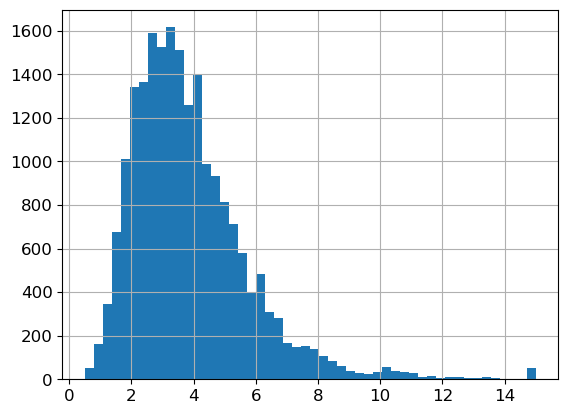

In [29]:
housing["median_income"].hist(bins=50);
plt.show()

In [30]:
len(housing["median_income"].unique())

12928

In [31]:
housing['median_income'].describe()

count    20640.000000
mean         3.870671
std          1.899822
min          0.499900
25%          2.563400
50%          3.534800
75%          4.743250
max         15.000100
Name: median_income, dtype: float64

The following code uses the `pd.cut()` function to create an income category attribute with five categories (labeled from 1 to 5): 
- category 1 ranges from 0 to 1.5 (i.e., less than 15,000), category 2 from 1.5 to 3, and so on.

In [32]:
housing["income_cat"] = pd.cut(housing["median_income"], bins=[0.,1.5,3.0,4.5,6.,np.inf], labels=[1,2,3,4,5])

housing[['median_income', 'income_cat']].head()


,median_income,income_cat
0,8.3252,5
1,8.3014,5
2,7.2574,5
3,5.6431,4
4,3.8462,3


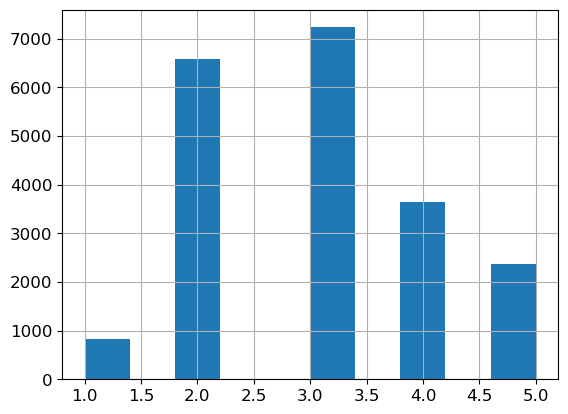

In [33]:
housing["income_cat"].hist()
plt.show()

In [34]:
# Divide by 1.5 to limit the number of income categories
housing["income_cat"] = np.ceil(housing["median_income"] / 1.5)

# Label those above 5 as 5
housing["income_cat"].where(housing["income_cat"] < 5, 5.0, inplace=True)

/var/folders/b6/lcs0bdlx0f3666dlb0n6q_240000gn/T/ipykernel_8695/938058708.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  housing["income_cat"].where(housing["income_cat"] < 5, 5.0, inplace=True)


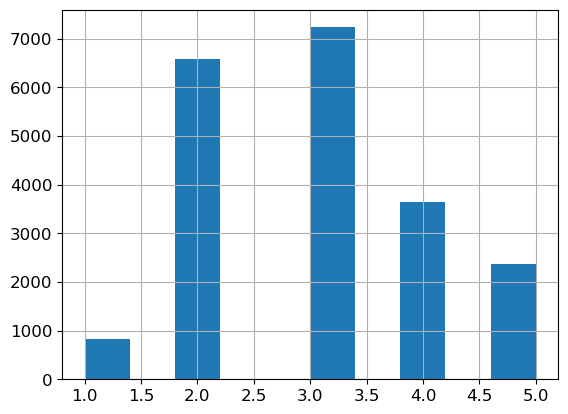

In [35]:
housing["income_cat"].hist()
plt.show()

In [36]:
housing["income_cat"].value_counts()

income_cat
3.0    7236
2.0    6581
4.0    3639
5.0    2362
1.0     822
Name: count, dtype: int64

In [37]:
from sklearn.model_selection import StratifiedShuffleSplit

# Create dataset generator
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_index, test_index in split.split(housing, housing["income_cat"]):
    strat_train_set = housing.loc[train_index]
    strat_test_set = housing.loc[test_index]

In [38]:
train_index

array([12655, 15502,  2908, ..., 19263, 19140, 19773])

In [39]:
strat_train_set.shape

(16512, 11)

In [40]:
strat_test_set.shape

(4128, 11)

In [41]:
strat_test_set["income_cat"].value_counts() / len(strat_test_set)

income_cat
3.0    0.350533
2.0    0.318798
4.0    0.176357
5.0    0.114341
1.0    0.039971
Name: count, dtype: float64

In [42]:
strat_train_set["income_cat"].value_counts() / len(strat_train_set)

income_cat
3.0    0.350594
2.0    0.318859
4.0    0.176296
5.0    0.114462
1.0    0.039789
Name: count, dtype: float64

In [43]:
housing.shape

(20640, 11)

In [44]:
housing["income_cat"].value_counts() / len(housing)

income_cat
3.0    0.350581
2.0    0.318847
4.0    0.176308
5.0    0.114438
1.0    0.039826
Name: count, dtype: float64

In [45]:
from sklearn.model_selection import train_test_split
def income_cat_proportions(data):
    return data["income_cat"].value_counts() / len(data)

train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)

compare_props = pd.DataFrame({
    "Overall": income_cat_proportions(housing),
    "Stratified": income_cat_proportions(strat_test_set),
    "Random": income_cat_proportions(test_set),
}).sort_index()
compare_props["Rand. %error"] = 100 * compare_props["Random"] / compare_props["Overall"] - 100
compare_props["Strat. %error"] = 100 * compare_props["Stratified"] / compare_props["Overall"] - 100

In [46]:
compare_props

,Overall,Stratified,Random,Rand. %error,Strat. %error
income_cat,,,,,
1.0,0.039826,0.039971,0.040213,0.973236,0.364964
2.0,0.318847,0.318798,0.324370,1.732260,-0.015195
3.0,0.350581,0.350533,0.358527,2.266446,-0.013820
4.0,0.176308,0.176357,0.167393,-5.056334,0.027480
5.0,0.114438,0.114341,0.109496,-4.318374,-0.084674


In [47]:
# Remove income_cat attribute
for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True)

In [48]:
strat_train_set.shape

(16512, 10)

# Discover and visualize the data to gain insights
*** 
Make sure to look at **ONLY the training set** when exploring the data.

In [49]:
# Extract ONLY the training set 
housing = strat_train_set.copy()

## Visualize the data

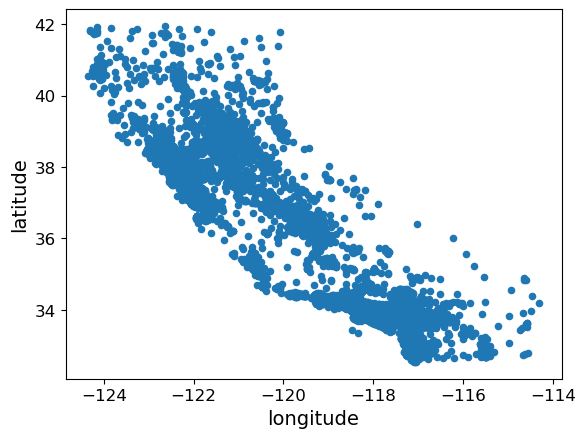

In [50]:
housing.plot(kind="scatter", x="longitude", y="latitude");
# save_fig("bad_visualization_plot")
plt.show()

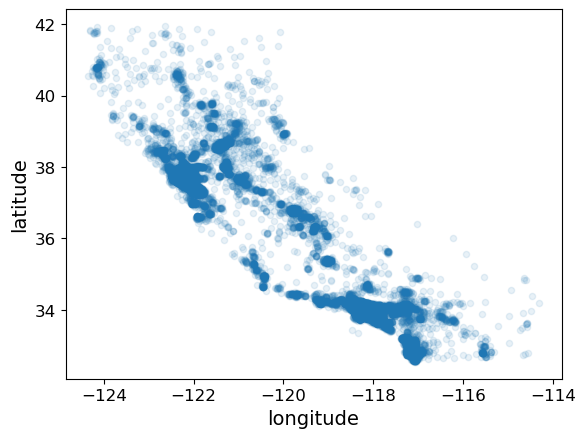

In [51]:
housing.plot(kind="scatter", x="longitude", y="latitude", alpha=0.1)
plt.show()
# save_fig("better_visualization_plot")

The argument `sharex=False` fixes a display bug (the x-axis values and legend were not displayed). This is a temporary fix (see: https://github.com/pandas-dev/pandas/issues/10611). Thanks to Wilmer Arellano for pointing it out.

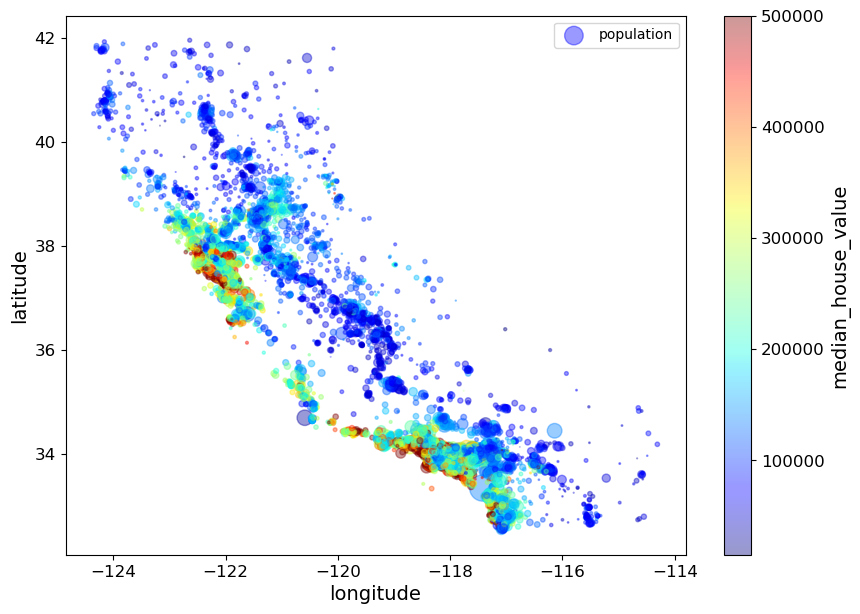

In [52]:
# Use arg 's' to set size, and arg 'c' to set color
housing.plot(kind="scatter", x="longitude", y="latitude", alpha=0.4,
    s=housing["population"]/100, label="population", figsize=(10,7),
    c="median_house_value", cmap=plt.get_cmap("jet"), colorbar=True,
    sharex=False)
plt.legend()
plt.show()
# save_fig("housing_prices_scatterplot")

/var/folders/b6/lcs0bdlx0f3666dlb0n6q_240000gn/T/ipykernel_8695/956623631.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  cbar.ax.set_yticklabels(["$%dk"%(round(v/1000)) for v in tick_values], fontsize=14)


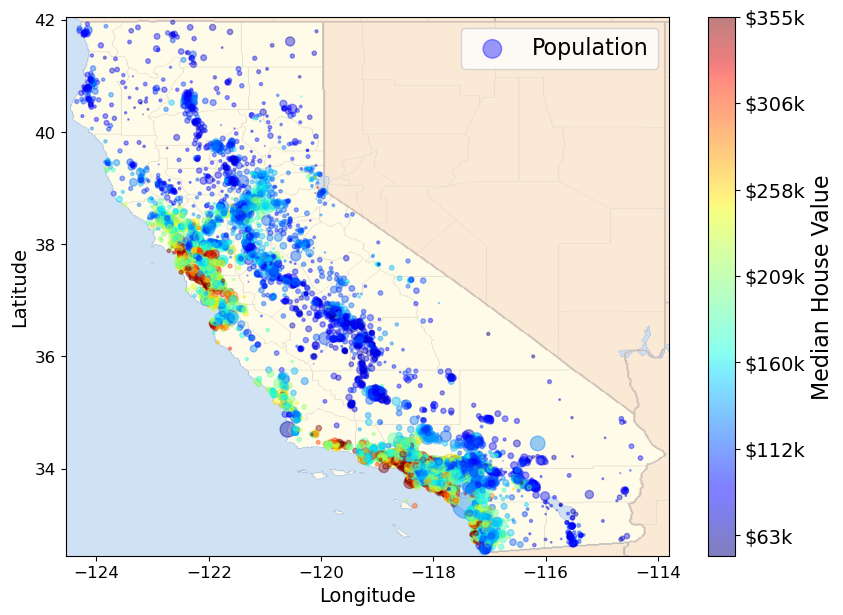

In [53]:
# https://raw.githubusercontent.com/ageron/handson-ml/master/images/end_to_end_project/california.png
import matplotlib.image as mpimg
california_img=mpimg.imread('images_module02/california.png')
ax = housing.plot(kind="scatter", x="longitude", y="latitude", figsize=(10,7),
                   s=housing['population']/100, label="Population",
                   c="median_house_value", cmap=plt.get_cmap("jet"),
                   colorbar=False, alpha=0.4,
                      )
plt.imshow(california_img, extent=[-124.55, -113.80, 32.45, 42.05], alpha=0.5,
           cmap=plt.get_cmap("jet"))
plt.ylabel("Latitude", fontsize=14)
plt.xlabel("Longitude", fontsize=14)

prices = housing["median_house_value"]
tick_values = np.linspace(prices.min(), prices.max(), 11)
cbar = plt.colorbar()
cbar.ax.set_yticklabels(["$%dk"%(round(v/1000)) for v in tick_values], fontsize=14)
cbar.set_label('Median House Value', fontsize=16)

plt.legend(fontsize=16)
plt.show()

## Explore Correlations

> Recap: correlations reveal relationships between variables. 

<img src="images_module02/correlations_visual.png" width="600"/>

> An intuitive way of interpreting the correlation coefficient of variables x and y is as follows: “if I know x, how much does that tell me about the value of y?". Pick a value of x and look at the values of y along that slice of the scatterplot. Does their mean change as a function of x? 
* If knowing x tells me nothing about y, the correlation is zero. 
* On the other hand, if knowing x allows me to pinpoint y pretty well, the correlation will approach 1. 
* A positive correlation means the values of x and y tend to move in the same direction; a negative correlation means they tend to move in opposite directions (i.e., when one goes higher, the other goes lower). 




The image above tells you that the housing prices are very much related to the location (e.g., close to the ocean) and to the population density (duh). **A clustering algorithm should be useful for detecting the main cluster and for adding new features that measure the proximity to the cluster centers.** 

The ocean proximity attribute may be useful as well, although in Northern California **the housing prices in coastal districts are not too high, so it is not a simple rule.**

We can examine these relationships even further by looking at the **standard correlation coefficients** between every single attribute:


In [54]:
corr_matrix = housing.corr(numeric_only=True)
corr_matrix

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.924478,-0.105823,0.048909,0.076686,0.108071,0.063146,-0.019615,-0.047466
latitude,-0.924478,1.000000,0.005737,-0.039245,-0.072550,-0.115290,-0.077765,-0.075146,-0.142673
housing_median_age,-0.105823,0.005737,1.000000,-0.364535,-0.325101,-0.298737,-0.306473,-0.111315,0.114146
total_rooms,0.048909,-0.039245,-0.364535,1.000000,0.929391,0.855103,0.918396,0.200133,0.135140
total_bedrooms,0.076686,-0.072550,-0.325101,0.929391,1.000000,0.876324,0.980167,-0.009643,0.047781
population,0.108071,-0.115290,-0.298737,0.855103,0.876324,1.000000,0.904639,0.002421,-0.026882
households,0.063146,-0.077765,-0.306473,0.918396,0.980167,0.904639,1.000000,0.010869,0.064590
median_income,-0.019615,-0.075146,-0.111315,0.200133,-0.009643,0.002421,0.010869,1.000000,0.687151
median_house_value,-0.047466,-0.142673,0.114146,0.135140,0.047781,-0.026882,0.064590,0.687151,1.000000


In [55]:
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.687151
total_rooms           0.135140
housing_median_age    0.114146
households            0.064590
total_bedrooms        0.047781
population           -0.026882
longitude            -0.047466
latitude             -0.142673
Name: median_house_value, dtype: float64

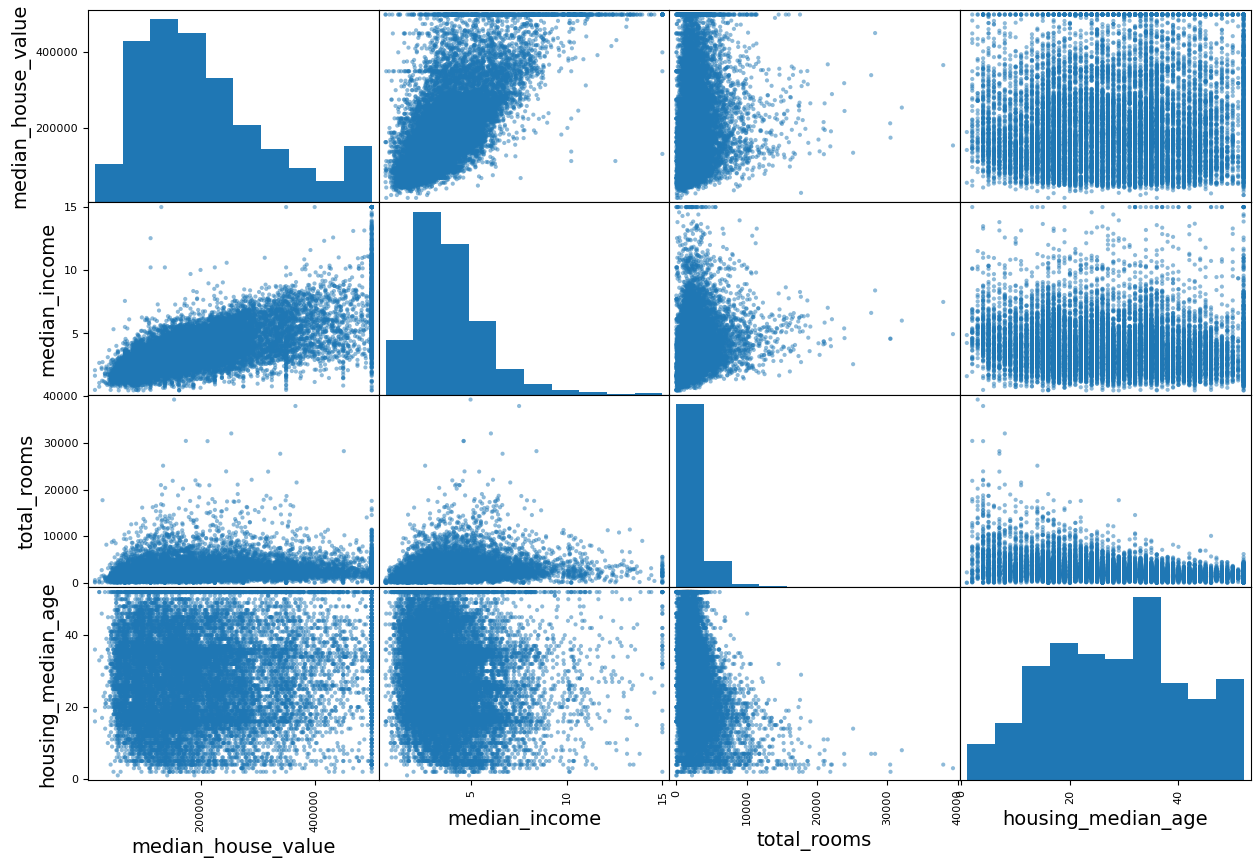

In [56]:
# from pandas.tools.plotting import scatter_matrix # For older versions of Pandas
from pandas.plotting import scatter_matrix

attributes = ["median_house_value", "median_income", "total_rooms", "housing_median_age"]
scatter_matrix(housing[attributes], figsize=(15, 10))
plt.show()
# save_fig("scatter_matrix_plot")

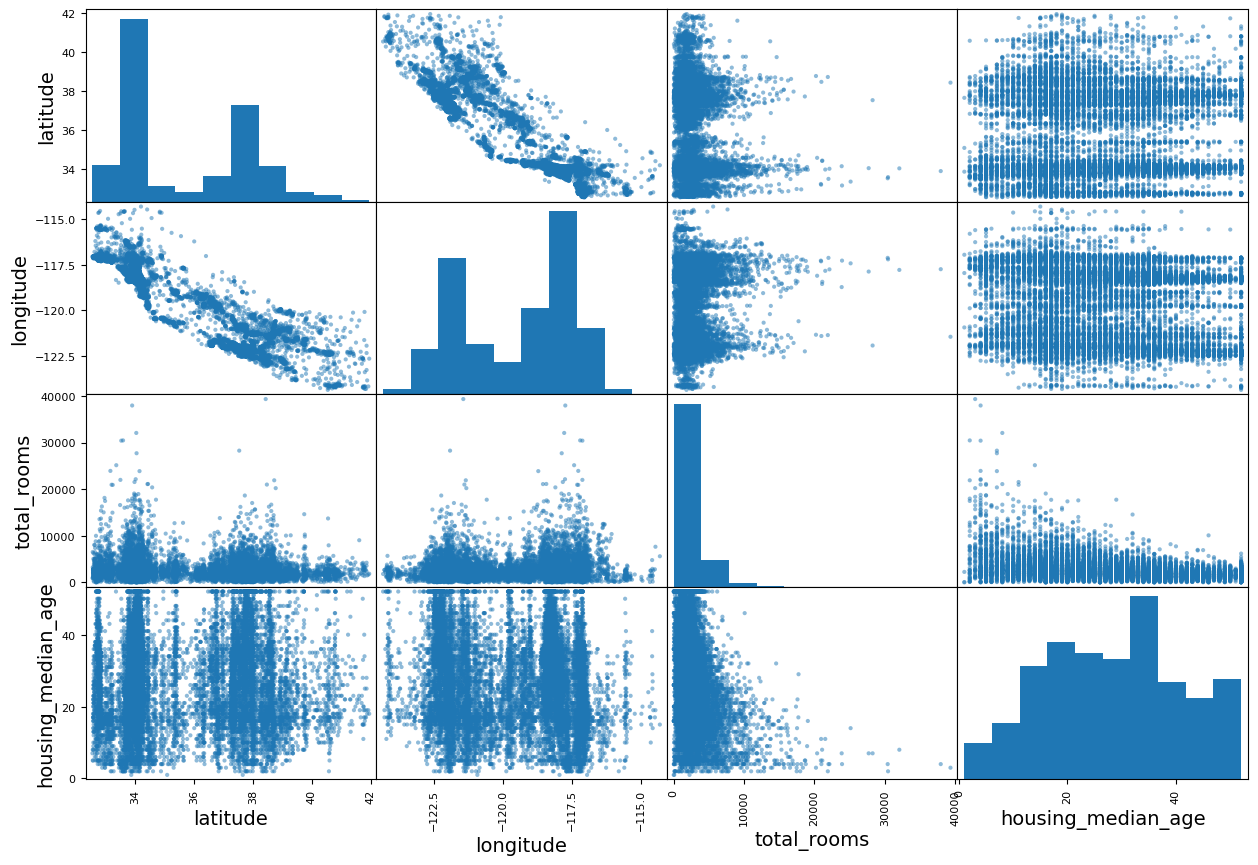

In [57]:
attributes = ["latitude", "longitude", "total_rooms", "housing_median_age"]
scatter_matrix(housing[attributes], figsize=(15, 10))
plt.show()


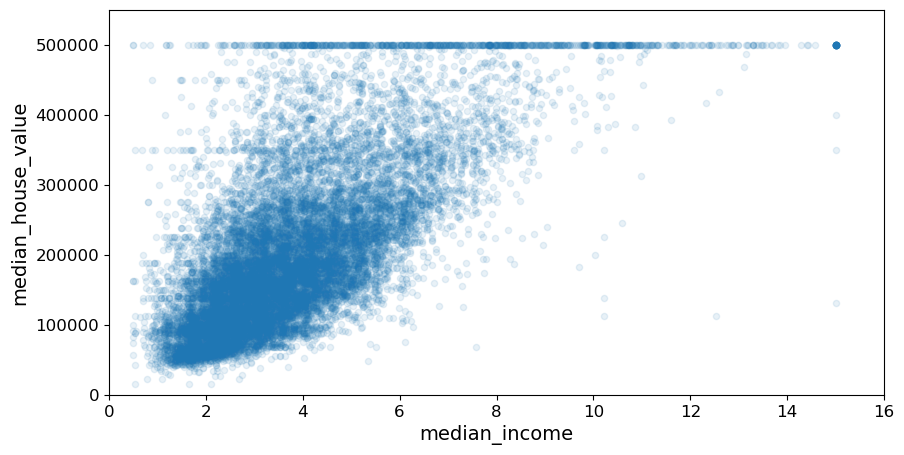

In [58]:
housing.plot(kind="scatter", x="median_income", y="median_house_value", alpha=0.1, figsize=(10,5))
plt.axis([0, 16, 0, 550000])
plt.show()
# save_fig("income_vs_house_value_scatterplot")

In [59]:
housing.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

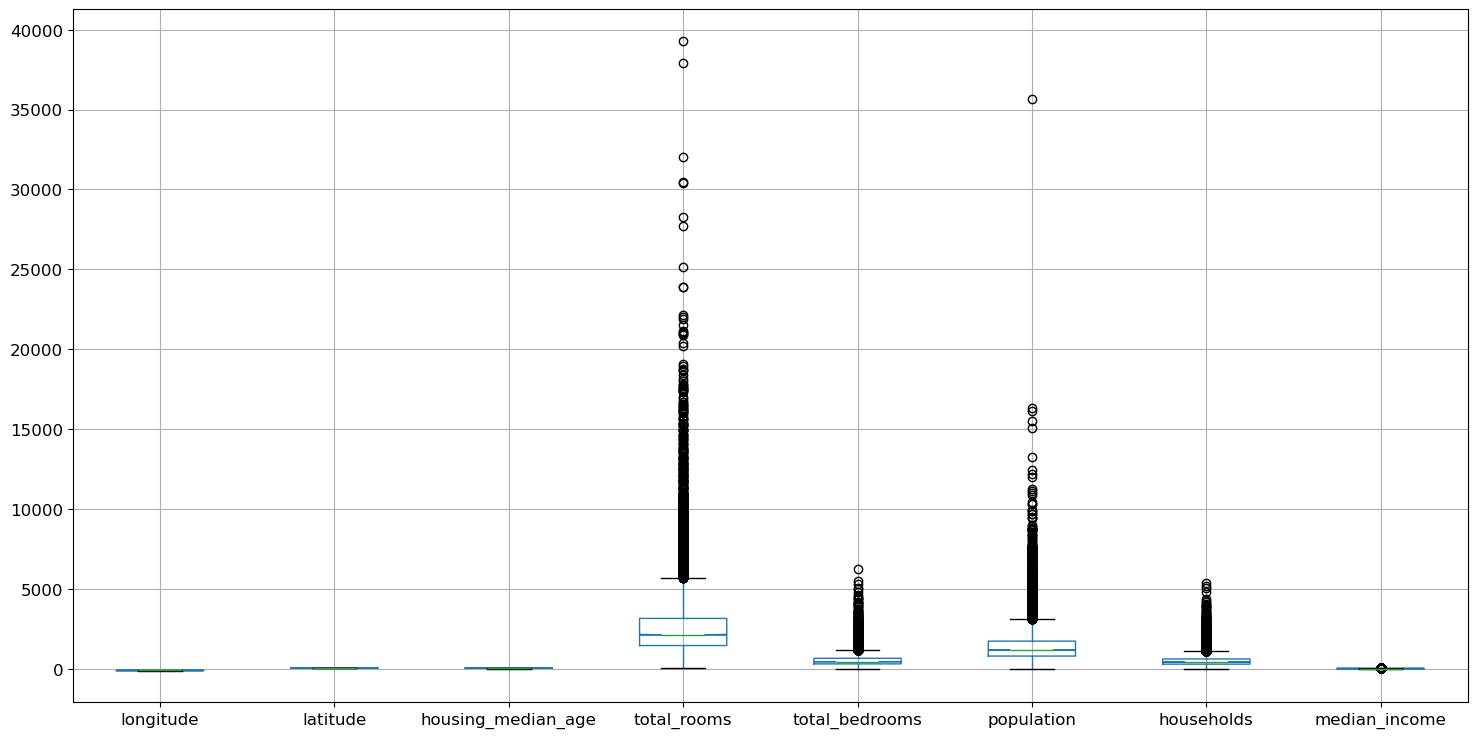

In [60]:
plt.figure(figsize=(18,9))
continuous_feats = ['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income']
housing.boxplot(column=continuous_feats, notch = True);#, layout=(int(len(cols)/3)+1,3))
plt.show()

## Experimenting with Attribute Combinations

One last thing you may want to do before preparing the data for Machine Learning algorithms is to try out various attribute combinations. For example:
- Average number of rooms per household
- Average number of bedrooms per household

This process is especially important for simple linear algorithms that don't implicitly combine attributes. 

**And it also helps with the EXPLAINABILITY of your model!!!**


In [61]:
housing["rooms_per_household"] = housing["total_rooms"]/housing["households"]
housing["bedrooms_per_room"] = housing["total_bedrooms"]/housing["total_rooms"]
housing["population_per_household"]=housing["population"]/housing["households"]

Note: there was a bug in the previous cell, in the definition of the `rooms_per_household` attribute. This explains why the correlation value below differs slightly from the value in the book (unless you are reading the latest version).

In [62]:
import seaborn as sns
def plot_corr(df, fill_diagonal=True, display_df=True, sort_by=None, method='pearson'):
    """NOTE: pd.plotting.scatter_matrix might be more useful"""
    cm = sns.light_palette("green", as_cmap=True)
    corr = df.corr(method=method, numeric_only=True)
    corr_np = corr.copy()
    if fill_diagonal:
        np.fill_diagonal(corr_np.values, corr_np.mean())
    corr = pd.DataFrame(corr_np, columns=corr.columns, index=corr.index)
    if sort_by:
        corr = corr.sort_values(sort_by)
    corr = corr.style.background_gradient(cmap=cm).format(precision=3).highlight_null('red')
    if display_df:
        display(corr)
    else:
        return corr
    
plot_corr(housing, sort_by='median_house_value')

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,rooms_per_household,bedrooms_per_room,population_per_household
bedrooms_per_room,0.096,-0.117,0.137,-0.193,0.087,0.038,0.067,-0.625,-0.260,-0.399,-0.014,0.004
latitude,-0.924,-0.037,0.006,-0.039,-0.073,-0.115,-0.078,-0.075,-0.143,0.108,-0.117,0.005
longitude,0.022,-0.924,-0.106,0.049,0.077,0.108,0.063,-0.020,-0.047,-0.028,0.096,-0.000
population,0.108,-0.115,-0.299,0.855,0.876,0.279,0.905,0.002,-0.027,-0.075,0.038,0.076
population_per_household,-0.000,0.005,0.015,-0.025,-0.028,0.076,-0.027,0.022,-0.022,-0.005,0.004,0.085
total_bedrooms,0.077,-0.073,-0.325,0.929,0.297,0.876,0.980,-0.010,0.048,0.000,0.087,-0.028
households,0.063,-0.078,-0.306,0.918,0.980,0.905,0.293,0.011,0.065,-0.083,0.067,-0.027
housing_median_age,-0.106,0.006,-0.032,-0.365,-0.325,-0.299,-0.306,-0.111,0.114,-0.147,0.137,0.015
total_rooms,0.049,-0.039,-0.365,0.299,0.929,0.855,0.918,0.200,0.135,0.128,-0.193,-0.025
median_house_value,-0.047,-0.143,0.114,0.135,0.048,-0.027,0.065,0.687,0.141,0.146,-0.260,-0.022


In [63]:
corr_matrix = housing.corr(numeric_only=True)
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value          1.000000
median_income               0.687151
rooms_per_household         0.146255
total_rooms                 0.135140
housing_median_age          0.114146
households                  0.064590
total_bedrooms              0.047781
population_per_household   -0.021991
population                 -0.026882
longitude                  -0.047466
latitude                   -0.142673
bedrooms_per_room          -0.259952
Name: median_house_value, dtype: float64

Apparently houses with a **lower bedroom/room ratio tend to be more expensive.** The number of rooms per household is also more informative than the total number of rooms in a district – obviously the larger the houses, the more expensive they are. 


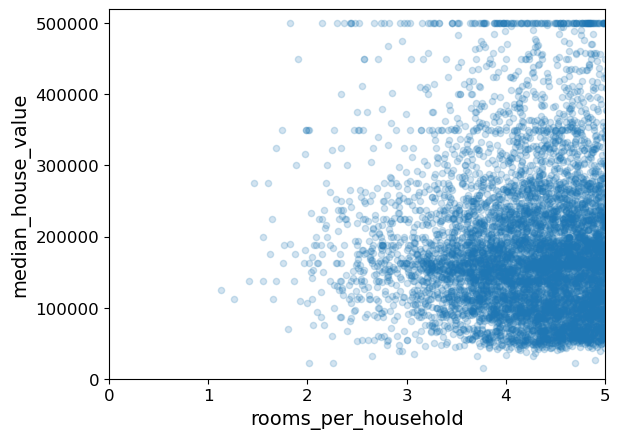

In [64]:
housing.plot(kind="scatter", x="rooms_per_household", y="median_house_value",
             alpha=0.2)
plt.axis([0, 5, 0, 520000])
plt.show()

In [65]:
print(housing.shape)
housing.describe()

(16512, 13)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,rooms_per_household,bedrooms_per_room,population_per_household
count,16512.000000,16512.000000,16512.000000,16512.000000,16354.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16354.000000,16512.000000
mean,-119.575635,35.639314,28.653404,2622.539789,534.914639,1419.687379,497.011810,3.875884,207005.322372,5.440406,0.212873,3.096469
std,2.001828,2.137963,12.574819,2138.417080,412.665649,1115.663036,375.696156,1.904931,115701.297250,2.611696,0.057378,11.584825
min,-124.350000,32.540000,1.000000,6.000000,2.000000,3.000000,2.000000,0.499900,14999.000000,1.130435,0.100000,0.692308
25%,-121.800000,33.940000,18.000000,1443.000000,295.000000,784.000000,279.000000,2.566950,119800.000000,4.442168,0.175304,2.431352
50%,-118.510000,34.260000,29.000000,2119.000000,433.000000,1164.000000,408.000000,3.541550,179500.000000,5.232342,0.203027,2.817661
75%,-118.010000,37.720000,37.000000,3141.000000,644.000000,1719.000000,602.000000,4.745325,263900.000000,6.056361,0.239816,3.281420
max,-114.310000,41.950000,52.000000,39320.000000,6210.000000,35682.000000,5358.000000,15.000100,500001.000000,141.909091,1.000000,1243.333333


# Prepare the data for Machine Learning algorithms
***

It’s time to prepare the data for your Machine Learning algorithms. Instead of doing this manually, you should **write functions for this purpose,** for several good reasons:
- This will allow you to **reproduce these transformations easily on any dataset** (e.g., the next time you get a fresh dataset).
- You will gradually build a **library of transformation functions** that you can reuse in future projects.
- You can use these functions in your **live system** to transform the new data before feeding it to your algorithms.
- This will make it possible for you to easily **try various transformations and see which combination of transformations works best**.


But first let’s revert to a clean training set (by copying strat_train_set once again). 


In [66]:
housing = strat_train_set.drop("median_house_value", axis=1).copy() # drop labels for training set
housing_labels = strat_train_set["median_house_value"].copy()

## Missing Values


In [67]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16512 entries, 12655 to 19773
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           16512 non-null  float64
 1   latitude            16512 non-null  float64
 2   housing_median_age  16512 non-null  float64
 3   total_rooms         16512 non-null  float64
 4   total_bedrooms      16354 non-null  float64
 5   population          16512 non-null  float64
 6   households          16512 non-null  float64
 7   median_income       16512 non-null  float64
 8   ocean_proximity     16512 non-null  object 
dtypes: float64(8), object(1)
memory usage: 1.3+ MB


First things first, we need to handle **missing values.**

The `total_bedrooms` attribute seems to have ~200 missing values, so let’s fix this. You have three options: 
1. Get rid of the corresponding districts.
2. Get rid of the whole attribute.
3. Set the values to some value (zero, the mean, the median, etc.).

You can accomplish these easily using DataFrame’s `dropna()`, `drop()` , and `fillna()` methods: 

In [68]:
(16512-16354)/16512

0.009568798449612403

In [69]:
sample_incomplete_rows = housing[housing.isnull().any(axis=1)]
print(sample_incomplete_rows.shape)
sample_incomplete_rows.head()

(158, 9)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
1606,-122.08,37.88,26.0,2947.0,NaN,825.0,626.0,2.9330,NEAR BAY
10915,-117.87,33.73,45.0,2264.0,NaN,1970.0,499.0,3.4193,<1H OCEAN
19150,-122.70,38.35,14.0,2313.0,NaN,954.0,397.0,3.7813,<1H OCEAN
4186,-118.23,34.13,48.0,1308.0,NaN,835.0,294.0,4.2891,<1H OCEAN
16885,-122.40,37.58,26.0,3281.0,NaN,1145.0,480.0,6.3580,NEAR OCEAN


In [70]:
sample_incomplete_rows.dropna(subset=["total_bedrooms"])    # option 1

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity


In [71]:
sample_incomplete_rows.drop("total_bedrooms", axis=1)       # option 2

,longitude,latitude,housing_median_age,total_rooms,population,households,median_income,ocean_proximity
1606,-122.08,37.88,26.0,2947.0,825.0,626.0,2.9330,NEAR BAY
10915,-117.87,33.73,45.0,2264.0,1970.0,499.0,3.4193,<1H OCEAN
19150,-122.70,38.35,14.0,2313.0,954.0,397.0,3.7813,<1H OCEAN
4186,-118.23,34.13,48.0,1308.0,835.0,294.0,4.2891,<1H OCEAN
16885,-122.40,37.58,26.0,3281.0,1145.0,480.0,6.3580,NEAR OCEAN
...,...,...,...,...,...,...,...,...
1350,-121.95,38.03,5.0,5526.0,3207.0,1012.0,4.0767,INLAND
4691,-118.37,34.07,50.0,2519.0,1117.0,516.0,4.3667,<1H OCEAN
9149,-118.50,34.46,17.0,10267.0,4956.0,1483.0,5.5061,<1H OCEAN
16757,-122.48,37.70,33.0,4492.0,3477.0,1537.0,3.0546,NEAR OCEAN


In [72]:
median = housing["total_bedrooms"].median()
sample_incomplete_rows["total_bedrooms"].fillna(median, inplace=True) # option 3
sample_incomplete_rows.head()

/var/folders/b6/lcs0bdlx0f3666dlb0n6q_240000gn/T/ipykernel_8695/3260431898.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  sample_incomplete_rows["total_bedrooms"].fillna(median, inplace=True) # option 3
/var/folders/b6/lcs0bdlx0f3666dlb0n6q_240000gn/T/ipykernel_8695/3260431898.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample_inc

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
1606,-122.08,37.88,26.0,2947.0,433.0,825.0,626.0,2.9330,NEAR BAY
10915,-117.87,33.73,45.0,2264.0,433.0,1970.0,499.0,3.4193,<1H OCEAN
19150,-122.70,38.35,14.0,2313.0,433.0,954.0,397.0,3.7813,<1H OCEAN
4186,-118.23,34.13,48.0,1308.0,433.0,835.0,294.0,4.2891,<1H OCEAN
16885,-122.40,37.58,26.0,3281.0,433.0,1145.0,480.0,6.3580,NEAR OCEAN


Scikit-Learn provides a handy class to take care of missing values: `SimpleImputer`. 

Here is how to use it. 
- **Initialize the Imputer**: First, you need to create a SimpleImputer instance, specifying that you want to replace each attribute’s missing values with the median of that attribute: 
    - Since the median can only be computed on numerical attributes, you need to create a copy of the data without the text attribute `ocean_proximity` : 
- **Fit the Imputer:** Now you can fit the imputer instance to the training data using the `fit()` method
- **Transform Data:** Now you can use this “trained” imputer to transform the training set by replacing missing values with the learned medians: 

In [73]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

Remove the text attribute because median can only be calculated on numerical attributes:

In [74]:
housing_num = housing.drop('ocean_proximity', axis=1)
# alternatively: housing_num = housing.select_dtypes(include=[np.number])

In [75]:
imputer.fit(housing_num)

SimpleImputer(strategy='median')

In [76]:
imputer.statistics_

array([-118.51   ,   34.26   ,   29.     , 2119.     ,  433.     ,
       1164.     ,  408.     ,    3.54155])

Check that this is the same as manually computing the median of each attribute:

In [77]:
housing_num.median().values

array([-118.51   ,   34.26   ,   29.     , 2119.     ,  433.     ,
       1164.     ,  408.     ,    3.54155])

The imputer has simply computed the median of each attribute and stored the result in its `statistics_` instance variable. 

Only the `total_bedrooms` and the `total_bedrooms_log` attributes had missing values, **but we cannot be sure that there won’t be any missing values in new data after the system goes live, so it is safer to apply the imputer to all the numerical attributes**.

Now lets transform the training set:

In [78]:
X = imputer.transform(housing_num)
X[0:5]

array([[-1.2146e+02,  3.8520e+01,  2.9000e+01,  3.8730e+03,  7.9700e+02,
         2.2370e+03,  7.0600e+02,  2.1736e+00],
       [-1.1723e+02,  3.3090e+01,  7.0000e+00,  5.3200e+03,  8.5500e+02,
         2.0150e+03,  7.6800e+02,  6.3373e+00],
       [-1.1904e+02,  3.5370e+01,  4.4000e+01,  1.6180e+03,  3.1000e+02,
         6.6700e+02,  3.0000e+02,  2.8750e+00],
       [-1.1713e+02,  3.2750e+01,  2.4000e+01,  1.8770e+03,  5.1900e+02,
         8.9800e+02,  4.8300e+02,  2.2264e+00],
       [-1.1870e+02,  3.4280e+01,  2.7000e+01,  3.5360e+03,  6.4600e+02,
         1.8370e+03,  5.8000e+02,  4.4964e+00]])

In [79]:
housing_tr = pd.DataFrame(X, columns=housing_num.columns, index = list(housing.index.values))

In [80]:
housing_tr.loc[sample_incomplete_rows.index.values]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
1606,-122.08,37.88,26.0,2947.0,433.0,825.0,626.0,2.9330
10915,-117.87,33.73,45.0,2264.0,433.0,1970.0,499.0,3.4193
19150,-122.70,38.35,14.0,2313.0,433.0,954.0,397.0,3.7813
4186,-118.23,34.13,48.0,1308.0,433.0,835.0,294.0,4.2891
16885,-122.40,37.58,26.0,3281.0,433.0,1145.0,480.0,6.3580
...,...,...,...,...,...,...,...,...
1350,-121.95,38.03,5.0,5526.0,433.0,3207.0,1012.0,4.0767
4691,-118.37,34.07,50.0,2519.0,433.0,1117.0,516.0,4.3667
9149,-118.50,34.46,17.0,10267.0,433.0,4956.0,1483.0,5.5061
16757,-122.48,37.70,33.0,4492.0,433.0,3477.0,1537.0,3.0546


**Notes on the Scikit-Learn API Design**

These are the main design principles: 

**Consistency**
- All objects share a consistent and simple interface: 
    - **Estimators:** 
        - Any object that can **estimate some parameters based on a dataset** is called an estimator (e.g., an imputer is an estimator). The estimation itself is performed by the `fit()` method, and it takes only a dataset as a parameter (or two for supervised learning algorithms; the second dataset contains the labels). 
        - Any other parameter needed to guide the estimation process is considered a hyperparameter (such as an imputer ’s strategy ), and it must be set as an instance variable (generally via a constructor parameter). 
    - **Transformers:** 
        - Some estimators (such as an imputer ) can also transform a dataset; these are called transformers . 
        - Once again, the API is simple: the transformation is performed by the `transform()` method with the dataset to transform as a parameter. It returns the transformed dataset. 
        - This transformation generally relies on the learned parameters, as is the case for an imputer . 
        - All transformers also have a convenience method called `fit_transform()` that is equivalent to calling `fit()` and then `transform()` (but sometimes `fit_transform()` is optimized and runs much faster). 
    - **Predictors:**
        - Finally, some estimators, given a dataset, are capable of making predictions; they are called predictors . 
        - For example, the LinearRegression model in the previous chapter was a predictor: given a country’s GDP per capita, it predicted life satisfaction. 
        - A predictor has a `predict()` method that takes a dataset of new instances and returns a dataset of corresponding predictions. 
        - It also has a `score()` method that measures the quality of the predictions, given a test set (and the corresponding labels, in the case of supervised learning algorithms). 
        
**Inspection**
- All the estimator’s hyperparameters are accessible directly via public instance variables (e.g., `imputer.strategy` ), and all the estimator’s learned parameters are accessible via public instance variables with an underscore suffix (e.g., `imputer.statistics_` ). 

**Nonproliferation of classes**
- Datasets are represented as NumPy arrays or SciPy sparse matrices, instead of homemade classes. 
- Hyperparameters are just regular Python strings or numbers. 

**Composition**
- Existing building blocks are reused as much as possible. For example, it is easy to create a `Pipeline` estimator from an arbitrary sequence of transformers followed by a final estimator, as we will see. 

**Sensible defaults**
- Scikit-Learn provides reasonable default values for most parameters, making it easy to quickly create a baseline working system. 


## Categorical Attributes

In this dataset, there is just one: the **ocean_proximity attribute**. 

NOTE: It is common practice  to split feature preprocessing into two steps in your pipeline: **numerical and categorical.**

In [81]:
housing_cat = housing[['ocean_proximity']]
housing_cat.head(10)

,ocean_proximity
12655,INLAND
15502,NEAR OCEAN
2908,INLAND
14053,NEAR OCEAN
20496,<1H OCEAN
1481,NEAR BAY
18125,<1H OCEAN
5830,<1H OCEAN
17989,<1H OCEAN
4861,<1H OCEAN


In [82]:
housing_cat['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     7277
INLAND        5262
NEAR OCEAN    2124
NEAR BAY      1847
ISLAND           2
Name: count, dtype: int64

In [83]:
# from future_encoders import OrdinalEncoder
from sklearn.preprocessing import OrdinalEncoder

In [84]:
ordinal_encoder = OrdinalEncoder()
housing_cat_encoded = ordinal_encoder.fit_transform(housing_cat)
housing_cat_encoded[:10]

array([[1.],
       [4.],
       [1.],
       [4.],
       [0.],
       [3.],
       [0.],
       [0.],
       [0.],
       [0.]])

In [85]:
ordinal_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

**Ordinal vs Categorical Variables**

One issue with this representation is that ML algorithms will assume that two nearby values are more similar than two distant values. This may be fine in some cases (e.g., for ordered categories such as “bad,” “average,” “good,” and “excellent”), but it is obviously not the case for the ocean_proximity column.

To fix this issue, a common solution is to create one binary attribute per category: one attribute equal to 1 when the category is “<1H OCEAN” (and 0 otherwise), another attribute equal to 1 when the category is “INLAND” (and 0 otherwise), and so on. **This is called one-hot encoding**.

The new attributes are sometimes called **dummy attributes**. Scikit-Learn provides a `OneHotEncoder` class to convert categorical values into one-hot vectors.

In [86]:
# from future_encoders import OneHotEncoder
from sklearn.preprocessing import OneHotEncoder
cat_encoder = OneHotEncoder()
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)
housing_cat_1hot

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 16512 stored elements and shape (16512, 5)>

By default, the `OneHotEncoder` class returns a sparse array, but we can convert it to a dense array if needed by calling the `toarray()` method:

In [87]:
housing_cat_1hot.toarray()

array([[0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 1.],
       [0., 1., 0., 0., 0.],
       ...,
       [1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.]])

Alternatively, you can set `sparse=False` when creating the `OneHotEncoder`:

(update: `sparse` has been renamed to `sparse_output`)

In [88]:
cat_encoder = OneHotEncoder(sparse_output=False)
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)
housing_cat_1hot

array([[0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 1.],
       [0., 1., 0., 0., 0.],
       ...,
       [1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.]])

In [89]:
cat_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

**NOTE:** If a categorical attribute has a **large number of possible categories (e.g., country code, profession, species),** then one-hot encoding will result in a large number of input features. 
- This may slow down training and degrade performance. 
- If this happens, you may want to **replace the categorical input with useful numerical features related to the categories.** 
- For example, you could replace the `ocean_proximity` feature with the distance to the ocean (similarly, a country code could be replaced with the country’s population and GDP per capita). 
- Alternatively, you could replace each category with a learnable, low-dimensional vector called an embedding. Each category’s representation would be learned during training. This is an example of **representation learning (see chapters 13 & 17 of HOML)**

## Feature Extraction with Custom Transformer

Although Scikit-Learn provides many useful transformers, you will need to write your own for tasks such as custom cleanup operations or combining specific attributes. **You will want your transformer to work seamlessly with Scikit-Learn functionalities (such as pipelines)**, and since Scikit-Learn relies on duck typing (not inheritance, see https://hackernoon.com/python-duck-typing-or-automatic-interfaces-73988ec9037f), all you need to do is create a class and implement three methods: 
- `fit()` (returning self), 
- `transform()` , 
- and `fit_transform()` . 

You can get the last one for free by simply adding `TransformerMixin` as a base class. If you add `BaseEstimator` as a base class (and avoid `*args` and `**kwargs` in your constructor), you will also get two extra methods ( `get_params()` and `set_params()` ) that will be useful for automatic hyperparameter tuning. 

Here is a small transformer class that adds the combined attributes we discussed earlier: 

In [90]:
from sklearn.base import BaseEstimator, TransformerMixin

# column index (NOT best practice!?)
rooms_ix, bedrooms_ix, population_ix, household_ix = 3, 4, 5, 6

class CombinedAttributesAdder(BaseEstimator, TransformerMixin):
    def __init__(self, add_bedrooms_per_room = True): # no *args or **kwargs
        self.add_bedrooms_per_room = add_bedrooms_per_room
    
    def fit(self, X, y=None):
        return self  # nothing else to do
    
    def transform(self, X, y=None):
        rooms_per_household = X[:, rooms_ix] / X[:, household_ix]
        population_per_household = X[:, population_ix] / X[:, household_ix]
        if self.add_bedrooms_per_room:
            bedrooms_per_room = X[:, bedrooms_ix] / X[:, rooms_ix]
            return np.c_[X, rooms_per_household, population_per_household,
                         bedrooms_per_room]
        else:
            return np.c_[X, rooms_per_household, population_per_household]

# Initialize the custom transformer
attr_adder = CombinedAttributesAdder(add_bedrooms_per_room=False)

# Call transform (pass in a numpy array)
housing_extra_attribs = attr_adder.transform(housing.values) # can also call fit_transform

In [91]:
housing_extra_attribs

array([[-121.46, 38.52, 29.0, ..., 'INLAND', 5.485835694050992,
        3.168555240793201],
       [-117.23, 33.09, 7.0, ..., 'NEAR OCEAN', 6.927083333333333,
        2.6236979166666665],
       [-119.04, 35.37, 44.0, ..., 'INLAND', 5.3933333333333335,
        2.223333333333333],
       ...,
       [-122.72, 38.44, 48.0, ..., '<1H OCEAN', 4.1104651162790695,
        2.6627906976744184],
       [-122.7, 38.31, 14.0, ..., '<1H OCEAN', 6.297405189620759,
        2.411177644710579],
       [-122.14, 39.97, 27.0, ..., 'INLAND', 5.477157360406092,
        3.1725888324873095]], dtype=object)

In [92]:
# Another example of a custom transformer
# Similar to OrdinalEncoder, but natively handles unknown or missing values

class CategoricalEncoder(BaseEstimator, TransformerMixin):
    def __init__(self): # no *args or **kwargs
        """
        Example:
            ce = CategoricalEncoder()
            ce.fit(X_train_clean[['Gender','Color1']])
            out = ce.transform(X_train_clean[['Gender','Color1']])
            # In
            pd.concat([X_train_clean.reset_index()[['Gender','Color1']],pd.DataFrame(out)], axis=1, ignore_index=True)
        """
        None
        
    def fit(self, X, y=None):
        """
        X must be of shape (n_samples, n_features)
        All missing or OOV values will be given UNK token, which is just n_unique_vals+1
        Where n_features>=1
        """
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X)
        self.vocab_index = []
        self.unk_token = []
        self.n_features = X.shape[-1]
        for col_idx in range(self.n_features):
            # Null values will be given n_values+1 token
            unique_vals = X.iloc[:,col_idx].dropna().sort_values().unique()
            self.vocab_index.append({v:idx for idx, v in enumerate(unique_vals)})
            self.unk_token.append(len(self.vocab_index[col_idx]))
        return self 
    
    def transform(self, X, y=None):
        if isinstance(X, pd.DataFrame):
            X = X.values
        mapped_cols = []
        for col_idx in range(self.n_features):
            # If token not present, use unk_token
            mapped_cols.append([self.vocab_index[col_idx].get(i, self.unk_token[col_idx]) for i in X[:, col_idx]])
        return np.stack(mapped_cols, axis=-1)

In [93]:
housing_extra_attribs = pd.DataFrame(
    housing_extra_attribs,
    columns=list(housing.columns)+["rooms_per_household", "population_per_household"])

housing_extra_attribs.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,rooms_per_household,population_per_household
0,-121.46,38.52,29.0,3873.0,797.0,2237.0,706.0,2.1736,INLAND,5.485836,3.168555
1,-117.23,33.09,7.0,5320.0,855.0,2015.0,768.0,6.3373,NEAR OCEAN,6.927083,2.623698
2,-119.04,35.37,44.0,1618.0,310.0,667.0,300.0,2.875,INLAND,5.393333,2.223333
3,-117.13,32.75,24.0,1877.0,519.0,898.0,483.0,2.2264,NEAR OCEAN,3.886128,1.859213
4,-118.7,34.28,27.0,3536.0,646.0,1837.0,580.0,4.4964,<1H OCEAN,6.096552,3.167241


## Feature Scaling

One of the most important transformations you need to apply to your data is **feature scaling**. 
- With few exceptions, Machine Learning algorithms **don’t perform well when the input numerical attributes have very different scales.**
- This is the case for the housing data: the total number of rooms ranges from about 6 to 39,320, while the median incomes only range from 0 to 15. 
- Note that **scaling the target values is generally not required.** 

There are two common ways to get all attributes to have the same scale: **min-max scaling and standardization.** 
- Min-max scaling (many people call this normalization ) is the simplest: values are shifted and rescaled so that they end up ranging from 0 to 1. 
    - We do this by subtracting the min value and dividing by the max minus the min. 
    - Scikit-Learn provides a transformer called `MinMaxScaler` for this. It has a `feature_range` hyperparameter that lets you change the range if, for some reason, you don’t want 0–1. 
- Standardization is different: first it subtracts the mean value (so standardized values always have a zero mean), and then it divides by the standard deviation so that the resulting distribution has unit variance.
    - Unlike min-max scaling, standardization **does not bound values to a specific range,** which may be a problem for some algorithms (e.g., neural networks often expect an input value ranging from 0 to 1).
    - However, standardization is much **less affected by outliers.** For example, suppose a district had a median income equal to 100 (by mistake). Min-max scaling would then crush all the other values from 0–15 down to 0–0.15, whereas standardization would not be much affected. 
    - Scikit-Learn provides a transformer called `StandardScaler` for standardization. 
    
**NOTE:** As with all the transformations, it is important to **fit the scalers to the training data only, not to the full dataset (including the test set).** Only then can you use them to transform the training set and the test set (and new data). 


In [94]:
from sklearn.preprocessing import StandardScaler

X = np.random.rand(10,5)
scaler = StandardScaler()

# Sklearn
X_scaled1 = scaler.fit_transform(X)

# Manual
X_scaled2 = (X-X.mean(axis=0))/X.std(axis=0)

X_scaled2==X_scaled1

array([[ True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True]])

## Build a pipeline

Sklearn's `Pipeline` constructor takes a list of **name/estimator pairs** defining a sequence of steps. **All but the last estimator must be transformers** (i.e., they must have a `fit_transform()` method). A few key points:
- The names can be anything you like (as long as they are unique and don’t contain double underscores, `__` )
- When you call the pipeline’s `fit()` method, it calls `fit_transform()` sequentially on all transformers, passing the output of each call as the parameter to the next call until it reaches the final estimator, for which it calls the `fit()` method. 
- The pipeline **exposes the same methods as the final estimator**.

In [95]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

num_pipeline = Pipeline([
#         ('imputer', Imputer(strategy="median")),
        ('imputer', SimpleImputer(strategy="median")),
        ('attribs_adder', CombinedAttributesAdder()),
        ('std_scaler', StandardScaler()),
    ])

housing_num_tr = num_pipeline.fit_transform(housing_num)

In [96]:
housing_num_tr.shape

(16512, 11)

In [97]:
housing_num_tr

array([[-0.94135046,  1.34743822,  0.02756357, ...,  0.01739526,
         0.00622264, -0.12112176],
       [ 1.17178212, -1.19243966, -1.72201763, ...,  0.56925554,
        -0.04081077, -0.81086696],
       [ 0.26758118, -0.1259716 ,  1.22045984, ..., -0.01802432,
        -0.07537122, -0.33827252],
       ...,
       [-1.5707942 ,  1.31001828,  1.53856552, ..., -0.5092404 ,
        -0.03743619,  0.32286937],
       [-1.56080303,  1.2492109 , -1.1653327 , ...,  0.32814891,
        -0.05915604, -0.45702273],
       [-1.28105026,  2.02567448, -0.13148926, ...,  0.01407228,
         0.00657083, -0.12169672]])

Next we will use sklearn's `ColumnTransformer` class to combine the pipelines of both the numerical and categorical attributes. 

The constructor requires a list of tuples, where each tuple contains:
- a name, 
- a transformer, 
- and a list of names (or indices) of columns that the transformer should be applied to. 

The `ColumnTransformer` applies each transformer to the appropriate columns and concatenates the outputs along the second axis **(the transformers must return the same number of rows).** 

A few things to note:
- The `OneHotEncoder` returns a sparse matrix, while the `num_pipeline` returns a dense matrix. 
    - When there is such a mix of sparse and dense matrices, the ColumnTransformer estimates the density of the final matrix (i.e., the ratio of nonzero cells), and it returns a sparse matrix if the density is lower than a given threshold (by default, sparse_threshold=0.3).
- Instead of using a transformer, you can specify the string **"drop"** if you want the columns to be dropped, or you can specify **"passthrough"** if you want the columns to be left untouched. 
- By default, **the remaining columns (i.e., the ones that were not listed) will be dropped, but you can set the remainder hyperparameter to any transformer (or to "passthrough" ) if you want these columns to be handled differently.**

In [98]:
from sklearn.compose import ColumnTransformer

In [99]:
# LIST OF COLUMNS MUST BE EXHAUSTIVE (unlisted columns will be dropped)
num_attribs = list(housing_num)
cat_attribs = ["ocean_proximity"]

full_pipeline = ColumnTransformer([
        ("num", num_pipeline, num_attribs),
        ("cat", OneHotEncoder(), cat_attribs),
    ])

housing_prepared = full_pipeline.fit_transform(housing)

In [100]:
housing_prepared.shape

(16512, 16)

In [101]:
housing_prepared

array([[-0.94135046,  1.34743822,  0.02756357, ...,  0.        ,
         0.        ,  0.        ],
       [ 1.17178212, -1.19243966, -1.72201763, ...,  0.        ,
         0.        ,  1.        ],
       [ 0.26758118, -0.1259716 ,  1.22045984, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [-1.5707942 ,  1.31001828,  1.53856552, ...,  0.        ,
         0.        ,  0.        ],
       [-1.56080303,  1.2492109 , -1.1653327 , ...,  0.        ,
         0.        ,  0.        ],
       [-1.28105026,  2.02567448, -0.13148926, ...,  0.        ,
         0.        ,  0.        ]])

For reference, here is the old solution based on a `DataFrameSelector` transformer (to just select a subset of the Pandas `DataFrame` columns), and a `FeatureUnion`:

In [102]:
from sklearn.base import BaseEstimator, TransformerMixin

# Create a class to select numerical or categorical columns 
class OldDataFrameSelector(BaseEstimator, TransformerMixin):
    def __init__(self, attribute_names):
        self.attribute_names = attribute_names
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        return X[self.attribute_names].values

Now let's join all these components into a big pipeline that will preprocess both the numerical and the categorical features:

In [103]:
num_attribs = list(housing_num)
cat_attribs = ["ocean_proximity"]

old_num_pipeline = Pipeline([
        ('selector', OldDataFrameSelector(num_attribs)),
        ('imputer', SimpleImputer(strategy="median")),
        ('attribs_adder', CombinedAttributesAdder()),
        ('std_scaler', StandardScaler()),
    ])

old_cat_pipeline = Pipeline([
        ('selector', OldDataFrameSelector(cat_attribs)),
        ('cat_encoder', OneHotEncoder(sparse_output=False)),
    ])

In [104]:
from sklearn.pipeline import FeatureUnion

old_full_pipeline = FeatureUnion(transformer_list=[
        ("num_pipeline", old_num_pipeline),
        ("cat_pipeline", old_cat_pipeline),
    ])

In [105]:
old_housing_prepared = old_full_pipeline.fit_transform(housing)
old_housing_prepared

array([[-0.94135046,  1.34743822,  0.02756357, ...,  0.        ,
         0.        ,  0.        ],
       [ 1.17178212, -1.19243966, -1.72201763, ...,  0.        ,
         0.        ,  1.        ],
       [ 0.26758118, -0.1259716 ,  1.22045984, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [-1.5707942 ,  1.31001828,  1.53856552, ...,  0.        ,
         0.        ,  0.        ],
       [-1.56080303,  1.2492109 , -1.1653327 , ...,  0.        ,
         0.        ,  0.        ],
       [-1.28105026,  2.02567448, -0.13148926, ...,  0.        ,
         0.        ,  0.        ]])

The result is the same as with the `ColumnTransformer`:

In [106]:
np.allclose(housing_prepared, old_housing_prepared, rtol=1e-30)

True

# Select and train a model 

In [107]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(housing_prepared, housing_labels)

LinearRegression()

In [108]:
# let's try the full preprocessing pipeline on a few training instances
some_data = housing.iloc[:5]
some_labels = housing_labels.iloc[:5]
some_data_prepared = full_pipeline.transform(some_data)

print("Predictions:", lin_reg.predict(some_data_prepared))

Predictions: [ 85657.90192014 305492.60737488 152056.46122456 186095.70946094
 244550.67966089]


Compare against the actual values:

In [109]:
print("Labels:", list(some_labels))

Labels: [72100.0, 279600.0, 82700.0, 112500.0, 238300.0]


In [110]:
some_data_prepared.shape

(5, 16)

In [111]:
from sklearn.metrics import mean_squared_error

# Get ALL predictions
housing_predictions = lin_reg.predict(housing_prepared)

# Calc RMSE
lin_mse = mean_squared_error(housing_labels, housing_predictions)
lin_rmse = np.sqrt(lin_mse)
lin_rmse

np.float64(68627.87390018745)

In [112]:
from sklearn.metrics import mean_absolute_error

lin_mae = mean_absolute_error(housing_labels, housing_predictions)
lin_mae

49438.66860915804

A decent start, but clearly not a great score: **most districts’ median_housing_values range between 120,000 and 265,000,** so a typical prediction error of 68,628 is not very satisfying. 

This is an example of a model underfitting the training data. When this happens it can mean that the **features do not provide enough information to make good predictions, or that the model is not powerful enough.** The main ways to fix underfitting are 
- to select a more powerful model, 
- to feed the training algorithm with better features,
- or to reduce the constraints on the model. 

This model is not regularized, which rules out the last option. You could try to add more features (e.g., the log of the population), but first let’s try a more complex model to see how it does. 

Let’s train a DecisionTreeRegressor. This is a powerful model, capable of finding complex **nonlinear relationships in the data** (we cover Decision Trees in  module 7).

In [113]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = DecisionTreeRegressor(random_state=42)
tree_reg.fit(housing_prepared, housing_labels)

DecisionTreeRegressor(random_state=42)

In [114]:
housing_predictions = tree_reg.predict(housing_prepared)
tree_mse = mean_squared_error(housing_labels, housing_predictions)
tree_rmse = np.sqrt(tree_mse)
tree_rmse

np.float64(0.0)

An MSE value of 0 is probably a sign that the model is overfitting!

# Fine-tune your model
***

Let's use Scikit-Learn’s **K-fold cross-validation** (CV) feature to evaluate our model. 

The following code randomly splits the training set into 10 distinct subsets called folds, then it trains and evaluates the Decision Tree model 10 times, picking a different fold for evaluation every time and training on the other 9 folds. The result is an array containing the 10 evaluation scores.

> Using CV helps us reduce bias in our estimate of model accuracy. If we only evaluated on one fold, that fold could coincidentally contain samples that are easier to predict; so by averaging over the entire training dataset, we get a more conservative estimate.

<img src="images_module02/cv_visual.png" width="600"/>

**NOTE:** Scikit-Learn’s cross-validation features expect a **utility function (greater is better) rather than a cost function (lower is better)** so the scoring function is actually the opposite of the MSE (i.e., a negative value).

In [115]:
# Custom function to time model training
import time
from time import time as now

def t_start():
    global t0
    t0 = now()

def t_end():
    global t0
    t_delt = (now() - t0)
    print("Training time: {:.3f} seconds".format(t_delt))

t_start()
time.sleep(2)
t_end()

Training time: 2.005 seconds


In [116]:
%%time
time.sleep(2)

CPU times: user 695 μs, sys: 1.73 ms, total: 2.43 ms
Wall time: 2.01 s


In [117]:
from sklearn.model_selection import cross_val_score

def display_scores(scores):
    print("Scores:", scores)
    print("Mean:", scores.mean())
    print("Standard deviation:", scores.std())

## DecisionTree 

In [118]:
t_start()
tree_reg = DecisionTreeRegressor(random_state=42)
scores = cross_val_score(tree_reg, housing_prepared, housing_labels, scoring="neg_mean_squared_error", cv=10)
t_end()

tree_rmse_scores = np.sqrt(-scores)

display_scores(tree_rmse_scores)

Training time: 1.170 seconds
Scores: [72831.45749112 69973.18438322 69528.56551415 72517.78229792
 69145.50006909 79094.74123727 68960.045444   73344.50225684
 69826.02473916 71077.09753998]
Mean: 71629.89009727491
Standard deviation: 2914.035468468928


Now the Decision Tree doesn’t look as good as it did earlier. **In fact, it seems to perform worse than the Linear Regression model!** 

Notice that cross-validation allows you to get not only an estimate of the performance of your model, but also a measure of how precise this estimate is (i.e., its standard deviation). 
The Decision Tree has a **score of approximately 71,630, generally ±2,914.** You would not have this information if you just used one validation set. 

**NOTE:** Cross-validation comes at the cost of training the model several times, so for large datasets this is likely not practical. 


## LinReg

In [119]:
t_start()
lin_reg = LinearRegression()
lin_scores = cross_val_score(lin_reg, housing_prepared, housing_labels, scoring="neg_mean_squared_error", cv=10)
t_end()

lin_rmse_scores = np.sqrt(-lin_scores)
display_scores(lin_rmse_scores)

Training time: 0.062 seconds
Scores: [71762.76364394 64114.99166359 67771.17124356 68635.19072082
 66846.14089488 72528.03725385 73997.08050233 68802.33629334
 66443.28836884 70139.79923956]
Mean: 69104.07998247066
Standard deviation: 2880.328209818069


## RandomForest

In [120]:
from sklearn.ensemble import RandomForestRegressor

# Train on just the training set (no cross validation)
t_start()
forest_reg = RandomForestRegressor(random_state=42)
forest_reg.fit(housing_prepared, housing_labels)
t_end()

# Look at rmse in on the training set
housing_predictions = forest_reg.predict(housing_prepared)
forest_mse = mean_squared_error(housing_labels, housing_predictions)
forest_rmse = np.sqrt(forest_mse)
print("RMSE on full training set:", forest_rmse)

Training time: 7.881 seconds
RMSE on full training set: 18650.698705770003


In [121]:
t_start()
forest_reg = RandomForestRegressor(random_state=42)
forest_scores = cross_val_score(forest_reg, housing_prepared, housing_labels, 
                                scoring="neg_mean_squared_error", cv=10)
t_end()

forest_rmse_scores = np.sqrt(-forest_scores)
display_scores(forest_rmse_scores)

Training time: 71.744 seconds
Scores: [51559.63379638 48737.57100062 47210.51269766 51875.21247297
 47577.50470123 51863.27467888 52746.34645573 50065.1762751
 48664.66818196 54055.90894609]
Mean: 50435.58092066179
Standard deviation: 2203.3381412764606


![](images_module02/model_training.png)

The Random Forests look very promising! However, note that the **score on the training set is still much lower than on the validation sets, meaning that the model is still overfitting the training set.** 
- Possible solutions for overfitting are to simplify the model, constrain it (i.e., regularize it), 
- or get a lot more training data. 

Before you dive much deeper into Random Forests, however, you should try out many other models from various categories of Machine Learning algorithms (e.g., several Support Vector Machines with different kernels, and possibly a neural network), without spending too much time tweaking the hyperparameters. The goal is to **shortlist a few (two to five) promising models**. 


## SVR

In [122]:
from sklearn.svm import SVR

# Train on just the training set (no cross validation)
t_start()
svm_reg = SVR(kernel="linear")
svm_reg.fit(housing_prepared, housing_labels)
t_end()

# Look at rmse in on the trining set
housing_predictions = svm_reg.predict(housing_prepared)
svm_mse = mean_squared_error(housing_labels, housing_predictions)
svm_rmse = np.sqrt(svm_mse)
print("RMSE on full training set:", svm_rmse)

Training time: 3.530 seconds
RMSE on full training set: 111095.06635291968


In [123]:
t_start()
svm_reg = SVR(kernel="linear")
svm_scores = cross_val_score(svm_reg, housing_prepared, housing_labels, 
                                scoring="neg_mean_squared_error", cv=10)
t_end()

svm_rmse_scores = np.sqrt(-svm_scores)
display_scores(svm_rmse_scores)

Training time: 30.408 seconds
Scores: [110518.40356474 112956.5486846  106998.56227015 113590.97575445
 107782.52294955 116063.7781669  113279.08892636 111836.81295967
 113168.96643781 111945.40954593]
Mean: 111814.1069260169
Standard deviation: 2600.840269089257


## Saving the results

In [124]:
import joblib
if not os.path.exists("model_scores.pkl"):
    models = [(lin_rmse_scores, "lin_reg", "r"),
              (tree_rmse_scores,"dt_reg", "b"),
              (forest_rmse_scores, "rf_reg", "g"),
              (svm_rmse_scores, "svm_reg", "y")]

    joblib.dump(models, "model_scores.pkl")

/var/folders/b6/lcs0bdlx0f3666dlb0n6q_240000gn/T/ipykernel_8695/2823544273.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([mod[0] for mod in model_scores],


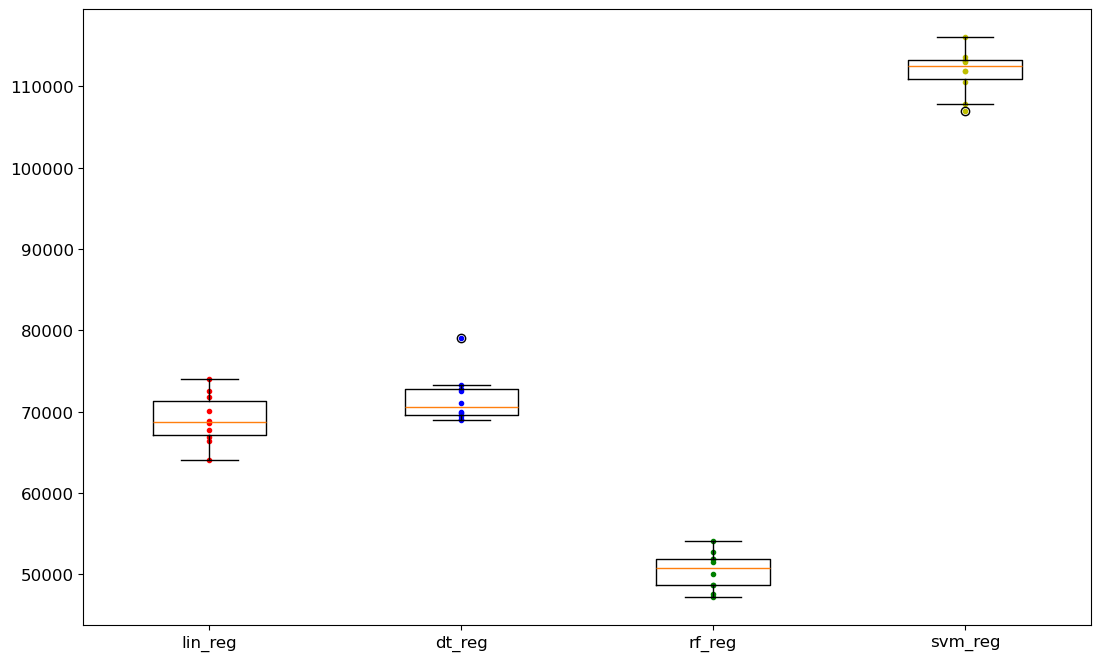

In [125]:
model_scores = joblib.load("model_scores.pkl")

# Plot scores
plt.figure(figsize=(13,8))
for idx, mod in enumerate(model_scores):
    plt.plot([idx+1]*10, mod[0], ".",c=mod[2])

# Plot boxes
plt.boxplot([mod[0] for mod in model_scores],
            labels=[mod[1] for mod in model_scores])
plt.show()

## Hyperparam tuning with GridSearch

Use grid search to test out a bunch of different hyperparameter combinations (without having to manually run each model individually). 

The following grid search will explore **8 x 8 = 64** combinations of RandomForestRegressor hyperparameter values, and it will **train each model 5 times** (since we are using five-fold cross validation). In other words, all in all, there will be **64 × 5 = 320 rounds of training!** 

**NOTE:** When you have no idea what value a hyperparameter should have, a simple approach is to try out consecutive powers of 10 (or a smaller number if you want a more fine-grained search, as shown in this example with the n_estimators hyperparameter). 


In [126]:
housing_prepared.shape

(16512, 16)

In [127]:
from sklearn.model_selection import GridSearchCV
import joblib 

param_grid = [
    {
        'n_estimators': [10, 30, 50], 
        'max_features': [2, 4, 6]
    },
  ]

#     {'bootstrap':[False], 'n_estimators': [10, 20, 30, 40, 50, 60, 70], 'max_features': [2, 4, 6, 8, 10, 12, 14, 16]},
    # then try 6 (2×3) combinations with bootstrap set as False
#     {'bootstrap': [False], 'n_estimators': [3, 10], 'max_features': [2, 3, 4]},
    

forest_reg = RandomForestRegressor(random_state=42)

# train across 5 folds, that's a total of (56)*5=280 rounds of training 
grid_search = GridSearchCV(forest_reg, param_grid, cv=3,
                           scoring='neg_mean_squared_error', 
                           return_train_score=True, 
                           verbose=2
                          )

t_start()
grid_search.fit(housing_prepared, housing_labels)
t_end()

# Save Model
joblib.dump(grid_search, "rf_gscv.pkl") 

grid_search

Fitting 3 folds for each of 9 candidates, totalling 27 fits
[CV] END ....................max_features=2, n_estimators=10; total time=   0.1s
[CV] END ....................max_features=2, n_estimators=10; total time=   0.1s
[CV] END ....................max_features=2, n_estimators=10; total time=   0.1s
[CV] END ....................max_features=2, n_estimators=30; total time=   0.3s
[CV] END ....................max_features=2, n_estimators=30; total time=   0.3s
[CV] END ....................max_features=2, n_estimators=30; total time=   0.3s
[CV] END ....................max_features=2, n_estimators=50; total time=   0.4s
[CV] END ....................max_features=2, n_estimators=50; total time=   0.4s
[CV] END ....................max_features=2, n_estimators=50; total time=   0.4s
[CV] END ....................max_features=4, n_estimators=10; total time=   0.1s
[CV] END ....................max_features=4, n_estimators=10; total time=   0.2s
[CV] END ....................max_features=4, n_es

GridSearchCV(cv=3, estimator=RandomForestRegressor(random_state=42),
             param_grid=[{'max_features': [2, 4, 6],
                          'n_estimators': [10, 30, 50]}],
             return_train_score=True, scoring='neg_mean_squared_error',
             verbose=2)

The best hyperparameter combination found:

In [128]:
# RELOAD TRAINED MODEL
grid_search = joblib.load("rf_gscv.pkl")

In [129]:
grid_search.best_params_

{'max_features': 4, 'n_estimators': 50}

In [130]:
# Best estimator is retrained on entire training set
grid_search.best_estimator_

RandomForestRegressor(max_features=4, n_estimators=50, random_state=42)

Let's look at the score of each hyperparameter combination tested during the grid search:

In [131]:
# https://python-graph-gallery.com/heatmap/
import seaborn as sns

# Extract score and params
cvres = grid_search.cv_results_
scores = np.sqrt(-cvres["mean_test_score"])
max_features = []
n_estimators = []
for i in cvres["params"]:
    max_features.append(i['max_features'])
    n_estimators.append(i['n_estimators'])
plt.show()

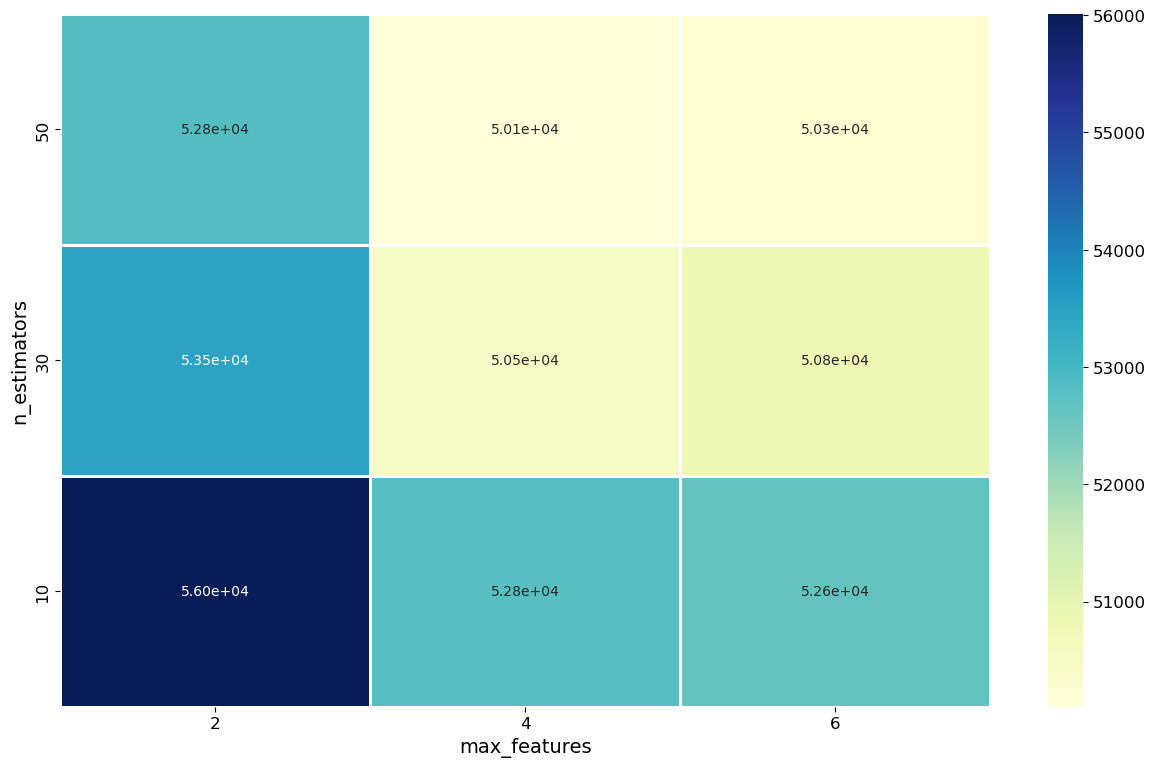

In [132]:
df = pd.DataFrame({"max_features":max_features, "n_estimators":n_estimators, "scores":scores})
df_pivot = df.pivot(columns='max_features', index='n_estimators', values='scores')

# Plot hyperparam heatmap
plt.figure(figsize=(15,9))
sns.heatmap(df_pivot, cmap="YlGnBu", annot=True, fmt='0.2e', linewidths=1, linecolor='white')
plt.gca().invert_yaxis()
plt.show()              

In [133]:
cvres = grid_search.cv_results_
for mean_score, params in zip(cvres["mean_test_score"], cvres["params"]):
    print(np.sqrt(-mean_score), params)

56012.21697810047 {'max_features': 2, 'n_estimators': 10}
53459.85342374432 {'max_features': 2, 'n_estimators': 30}
52847.756510104664 {'max_features': 2, 'n_estimators': 50}
52802.81436501343 {'max_features': 4, 'n_estimators': 10}
50515.53496227163 {'max_features': 4, 'n_estimators': 30}
50103.903139670605 {'max_features': 4, 'n_estimators': 50}
52644.56543208025 {'max_features': 6, 'n_estimators': 10}
50831.857685028204 {'max_features': 6, 'n_estimators': 30}
50264.21344097858 {'max_features': 6, 'n_estimators': 50}


In [134]:
pd.DataFrame(grid_search.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_features,param_n_estimators,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,mean_train_score,std_train_score
0,0.094845,0.016459,0.006920,0.000182,2,10,"{'max_features': 2, 'n_estimators': 10}",-2.985430e+09,-3.203795e+09,-3.222880e+09,-3.137368e+09,1.077187e+08,9,-5.984866e+08,-6.048243e+08,-5.953366e+08,-5.995492e+08,3.945516e+06
1,0.245255,0.002064,0.020111,0.000098,2,30,"{'max_features': 2, 'n_estimators': 30}",-2.758667e+09,-2.886613e+09,-2.928588e+09,-2.857956e+09,7.226881e+07,8,-4.542419e+08,-4.464834e+08,-4.276374e+08,-4.427876e+08,1.117121e+07
2,0.407105,0.001638,0.033127,0.000048,2,50,"{'max_features': 2, 'n_estimators': 50}",-2.699481e+09,-2.813735e+09,-2.865441e+09,-2.792885e+09,6.933841e+07,7,-4.230379e+08,-4.196559e+08,-4.007203e+08,-4.144714e+08,9.821003e+06
3,0.138501,0.003377,0.006948,0.000342,4,10,"{'max_features': 4, 'n_estimators': 10}",-2.647166e+09,-2.888987e+09,-2.828259e+09,-2.788137e+09,1.027187e+08,6,-5.220067e+08,-5.357986e+08,-5.403122e+08,-5.327058e+08,7.786608e+06
4,0.428387,0.005610,0.020335,0.000275,4,30,"{'max_features': 4, 'n_estimators': 30}",-2.449951e+09,-2.578847e+09,-2.626660e+09,-2.551819e+09,7.462957e+07,3,-3.959783e+08,-4.026872e+08,-3.910705e+08,-3.965787e+08,4.761447e+06
5,0.706162,0.006966,0.033207,0.000161,4,50,"{'max_features': 4, 'n_estimators': 50}",-2.416861e+09,-2.524242e+09,-2.590101e+09,-2.510401e+09,7.139899e+07,1,-3.736512e+08,-3.776313e+08,-3.674493e+08,-3.729106e+08,4.189639e+06
6,0.198386,0.006371,0.007076,0.000151,6,10,"{'max_features': 6, 'n_estimators': 10}",-2.698962e+09,-2.784321e+09,-2.831068e+09,-2.771450e+09,5.469425e+07,5,-5.193942e+08,-5.128344e+08,-5.361155e+08,-5.227813e+08,9.801588e+06
7,0.589858,0.000792,0.020033,0.000030,6,30,"{'max_features': 6, 'n_estimators': 30}",-2.471517e+09,-2.594241e+09,-2.685875e+09,-2.583878e+09,8.781749e+07,4,-3.970501e+08,-3.924175e+08,-4.029204e+08,-3.974627e+08,4.297723e+06
8,0.978448,0.005456,0.033407,0.000432,6,50,"{'max_features': 6, 'n_estimators': 50}",-2.427674e+09,-2.540882e+09,-2.610917e+09,-2.526491e+09,7.549755e+07,2,-3.728601e+08,-3.706383e+08,-3.704763e+08,-3.713249e+08,1.087569e+06


**NOTE:** Don’t forget that you can treat some of the data **preparation steps as hyperparameters.** 
- For example, the grid search will automatically find out whether or not to add a feature you were not sure about (e.g., using the add_bedrooms_per_room hyperparameter of your CombinedAttributesAdder transformer). 
- It may similarly be used to automatically find the best way to handle outliers, missing features, feature selection, and more. 


## Randomized Grid Search

When the **hyperparameter search space is large**, it is often preferable to use `RandomizedSearchCV` over `GridSearchCV`. This class can be used in much the same way as the GridSearchCV class, but instead of trying out all possible combinations, it evaluates a given number of random combinations by selecting a random value for each hyperparameter at every iteration. 

This approach has two main benefits: 
1. If you let the randomized search run for, say, 1,000 iterations, this approach will explore 1,000 different values for each hyperparameter.
2. Simply by setting the number of iterations, you have more control over the computing budget you want to allocate to hyperparameter search.

![](images_module02/grid_vs_random.png)

In [135]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_distribs = {
        'n_estimators': randint(low=1, high=200),
        'max_features': randint(low=1, high=8),
    }

forest_reg = RandomForestRegressor(random_state=42)
rnd_search = RandomizedSearchCV(forest_reg, param_distributions=param_distribs,
                                n_iter=10, cv=5, scoring='neg_mean_squared_error', random_state=42, verbose=2)
rnd_search.fit(housing_prepared, housing_labels)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END ...................max_features=7, n_estimators=180; total time=   5.1s
[CV] END ...................max_features=7, n_estimators=180; total time=   5.1s
[CV] END ...................max_features=7, n_estimators=180; total time=   5.1s
[CV] END ...................max_features=7, n_estimators=180; total time=   5.1s
[CV] END ...................max_features=7, n_estimators=180; total time=   5.2s
[CV] END ....................max_features=5, n_estimators=15; total time=   0.3s
[CV] END ....................max_features=5, n_estimators=15; total time=   0.3s
[CV] END ....................max_features=5, n_estimators=15; total time=   0.3s
[CV] END ....................max_features=5, n_estimators=15; total time=   0.3s
[CV] END ....................max_features=5, n_estimators=15; total time=   0.3s
[CV] END ....................max_features=3, n_estimators=72; total time=   1.0s
[CV] END ....................max_features=3, n_e

RandomizedSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42),
                   param_distributions={'max_features': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x339cfd0d0>,
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x339cff0e0>},
                   random_state=42, scoring='neg_mean_squared_error',
                   verbose=2)

In [136]:
cvres = rnd_search.cv_results_
for mean_score, params in zip(cvres["mean_test_score"], cvres["params"]):
    print(np.sqrt(-mean_score), params)

49117.55344336652 {'max_features': 7, 'n_estimators': 180}
51450.63202856348 {'max_features': 5, 'n_estimators': 15}
50700.386174457635 {'max_features': 3, 'n_estimators': 72}
50783.614493515 {'max_features': 5, 'n_estimators': 21}
49162.89877456354 {'max_features': 7, 'n_estimators': 122}
50663.56285209076 {'max_features': 3, 'n_estimators': 75}
50523.94360622104 {'max_features': 3, 'n_estimators': 88}
49521.76339475961 {'max_features': 5, 'n_estimators': 100}
50306.36122428185 {'max_features': 3, 'n_estimators': 150}
65167.02018649492 {'max_features': 5, 'n_estimators': 2}


In [137]:
feature_importances = rnd_search.best_estimator_.feature_importances_
feature_importances

array([7.13721236e-02, 6.28935545e-02, 4.30092772e-02, 1.64086555e-02,
       1.55670107e-02, 1.64745016e-02, 1.53753328e-02, 3.45190341e-01,
       5.95258394e-02, 1.10738856e-01, 6.97457058e-02, 8.67185471e-03,
       1.58662678e-01, 6.67961748e-05, 2.68890007e-03, 3.60857368e-03])

In [138]:
extra_attribs = ["rooms_per_hhold", "pop_per_hhold", "bedrooms_per_room"]
#cat_encoder = cat_pipeline.named_steps["cat_encoder"] # old solution
cat_encoder = full_pipeline.named_transformers_["cat"]
cat_one_hot_attribs = list(cat_encoder.categories_[0])
attributes = num_attribs + extra_attribs + cat_one_hot_attribs
sorted(zip(feature_importances, attributes), reverse=True)

[(np.float64(0.34519034100319007), 'median_income'),
 (np.float64(0.15866267751808205), 'INLAND'),
 (np.float64(0.1107388558918982), 'pop_per_hhold'),
 (np.float64(0.07137212359389712), 'longitude'),
 (np.float64(0.06974570580531124), 'bedrooms_per_room'),
 (np.float64(0.06289355447798799), 'latitude'),
 (np.float64(0.05952583935728965), 'rooms_per_hhold'),
 (np.float64(0.04300927718434754), 'housing_median_age'),
 (np.float64(0.016474501566255607), 'population'),
 (np.float64(0.016408655481155894), 'total_rooms'),
 (np.float64(0.015567010725199516), 'total_bedrooms'),
 (np.float64(0.015375332753137499), 'households'),
 (np.float64(0.008671854710510334), '<1H OCEAN'),
 (np.float64(0.003608573683092268), 'NEAR OCEAN'),
 (np.float64(0.002688900073839445), 'NEAR BAY'),
 (np.float64(6.679617480568294e-05), 'ISLAND')]

# Run Model on Test Set

**Make sure to transform the test data EXACTLY as you transformed the training data!**

In [139]:
final_model = rnd_search.best_estimator_

X_test = strat_test_set.drop("median_house_value", axis=1)
y_test = strat_test_set["median_house_value"].copy()

# RUN TRANSFORM, NOT FIT_TRANSFORM
X_test_prepared = full_pipeline.transform(X_test)
final_predictions = final_model.predict(X_test_prepared)

final_mse = mean_squared_error(y_test, final_predictions)
final_rmse = np.sqrt(final_mse)

In [140]:
final_rmse

np.float64(46981.841079394515)

We can compute a 95% confidence interval for the test RMSE:

In [141]:
from scipy import stats

In [142]:
confidence = 0.95
squared_errors = (final_predictions - y_test) ** 2
mean = squared_errors.mean()
m = len(squared_errors)

np.sqrt(stats.t.interval(confidence, 
                         m - 1,
                         loc=np.mean(squared_errors),
                         scale=stats.sem(squared_errors)))

array([45009.73121871, 48874.43992557])

We could compute the interval manually like this:

In [143]:
tscore = stats.t.ppf((1 + confidence) / 2, df=m - 1)
tmargin = tscore * squared_errors.std(ddof=1) / np.sqrt(m)
np.sqrt(mean - tmargin), np.sqrt(mean + tmargin)

(np.float64(45009.7312187091), np.float64(48874.439925573846))

Alternatively, we could use a z-scores rather than t-scores:

In [144]:
zscore = stats.norm.ppf((1 + confidence) / 2)
zmargin = zscore * squared_errors.std(ddof=1) / np.sqrt(m)
np.sqrt(mean - zmargin), np.sqrt(mean + zmargin)

(np.float64(45010.32226226666), np.float64(48873.895611725755))

# Deployment
***

Tutorials:
- AWS: https://aws.amazon.com/getting-started/tutorials/build-train-deploy-machine-learning-model-sagemaker/
- GCP: https://cloud.google.com/ml-engine/docs/deploying-models
- Medium: https://towardsdatascience.com/there-are-two-very-different-ways-to-deploy-ml-models-heres-both-ce2e97c7b9b1
- Medium again: https://towardsdatascience.com/simple-way-to-deploy-machine-learning-models-to-cloud-fd58b771fdcf

## The MLOps Workflow


<img src="images_module02/mlops_workflow.png" width="600"/>

Model training is usually not a one-time event. The data that we fit our models to is often dynamic. Over time we may gain access to more data, or richer data. The trends inherent in the data itself might change. Take the example of predicting housing prices: housing prices dramatically increased between 2020-2022 during the COVID pandemic. Model accuracy will decrease unless we retrain those models. 

In general, ML applications need a reproducible, reliable system for monitoring the performance of your models and updating them as necessary. This is the practice of MLOps, sometimes also called “Machine Learning Engineering”. It sets up a cycle of continuous improvement, wherein you can detect performance decay in your models, and leverage new data to improve them. 

MLOps systems typically consist of several services working in tandem:
* There are services that allow for the ingestion of new data. 
* That data has to be validated to check for quality (i.e. catch human errors, or even malicious attempts to spam the system with poor data), it needs to be pre-processed (cleaning, feature transformations, etc). 
* Trained models also need to be validated before deployment (do they produce reasonable outputs? Are they an improvement over the previous version?) 
* Models selected for deployment are typically published to a ‘model registry’, which stores the model artifacts for later retrieval, and also provides a record of previously deployed versions in case rollback is needed. 
* That model would then be ‘served’, such as through an endpoint over the cloud (e.g. where a real estate app can make queries to retrieve predicted home values). 
* Performance of that model on new incoming data would be monitored to detect for things like changing trends not yet accounted for by the model (e.g. during COVID, suburban homes were suddenly in demand while downtown homes cooled off). 

Such a system is usually built using cloud services (e.g. AWS, GCP, Azure) and tools such as Airflow (orchestration) and docker (containerization / code reproducibility). 

<img src="images_module02/mlops_codebase_breakdown.png" width="600"/>

MLOps isn’t just an afterthought. In the real world applications, the amount of code needed to deploy, manage, and maintain your models vastly exceeds the amount of code needed to train it. “Pure ML” code is typically no more than 5-15% of the total codebase. 

The above image was taken from this famous Google paper:  [Hidden Technical Debt in Machine Learning Systems](https://proceedings.neurips.cc/paper/2015/file/86df7dcfd896fcaf2674f757a2463eba-Paper.pdf)


# Extra material

## A full pipeline with both preparation and prediction

In [ ]:
full_pipeline_with_predictor = Pipeline([
        ("preparation", full_pipeline),
        ("linear", LinearRegression())
    ])

full_pipeline_with_predictor.fit(housing, housing_labels)
full_pipeline_with_predictor.predict(some_data)

## Model persistence using joblib

In [ ]:
my_model = full_pipeline_with_predictor

In [ ]:
joblib.dump(my_model, "my_model.pkl") # DIFF
#...
my_model_loaded = joblib.load("my_model.pkl") # DIFF

## Example SciPy distributions for `RandomizedSearchCV`

In [ ]:
from scipy.stats import geom, expon, reciprocal
geom_distrib=geom(0.5).rvs(10000, random_state=42)
expon_distrib=expon(scale=1).rvs(10000, random_state=42)
recip_distrib=reciprocal(20,20000).rvs(10000, random_state=42)

reciprocal
plt.hist(geom_distrib, bins=50)
plt.title('geom')
plt.show()
plt.hist(expon_distrib, bins=50)
plt.title('expon')
plt.show()
plt.hist(recip_distrib, bins=50)
plt.title('recip')
plt.show()

Congratulations! You already know quite a lot about Machine Learning. :)